
# 🏁 iRacing Telemetry → Coaching Pipeline (End-to-End)

This notebook builds a **complete, reproducible pipeline** to turn iRacing telemetry into **sector-level coaching**.

You will:
1. **Load** raw telemetry (from `.ibt` via `irsdk` or from a pre-saved CSV).
2. **Clean & normalize** the signals; convert units.
3. **Align laps** by distance percentage and visualize **time loss vs reference**.
4. **Split the lap into sectors**, compute sector statistics and deltas.
5. Build a **robust sector reference** (median of the top K% fastest laps).
6. Engineer features, **train a regressor** (LightGBM fallback to GradientBoosting), and report cross-validated metrics.
7. Apply a **per-sector residual bias correction** and re-evaluate metrics.
8. Generate **rule-based coaching** in milliseconds (ms).
9. (Optional) Call a **local LLM via Ollama** to produce **professional English coaching** using a structured JSON context.

> **Note:** All visuals use Matplotlib. No external internet is required. If `irsdk` is unavailable, you can work from CSV.



## 1. Environment checks & configuration

Fill the paths and flags below. If you don't have `.ibt` or `irsdk`, set `USE_IBT=False` and point to a CSV created earlier.


In [125]:

# --- Imports
import os, folium
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Explainability (LightGBM optional)
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False


# Optional irsdk (for .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False


# --- Paths & Parameters
USE_IBT = True  # set True to read a .ibt with irsdk if available




# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "/Users/morsinaldo/Developer/Racing4all/Iracing/data/"
#google_drive_path = "G:/Meu Drive/Estudos/Datasets - Simracing/Mazda - Charlotte/"

#Piloto A - Tomaz
driver_a = "Tomaz"
#ibt_file_A = google_drive_path + "mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt" #Tomaz

#Piloto B - Morsinaldo
driver_b = "Morsinaldo"
#1º Stint
#ibt_file_B = google_drive_path + "mx5 mx52016_charlotte 2025 roval2025 2026-01-27 16-13-55(Morsinaldo).ibt" #Morsinaldo

#2º Stint
#ibt_file_B = google_drive_path + "mx5 mx52016_charlotte 2025 roval2025 2026-01-28 15-24-41(Morsinaldo).ibt" #Morsinaldo

# Core pipeline settings
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30          # robust sector reference: median of fastest top K%
PACE_THRESHOLD_MS = 3000.0   # drop laps whose sum of positive sector losses > 2s
CLIP_MS = 1500.0             # clip training target (ms)
SEQ_LEN = 128                # per-sector resampling for stability
SEED = 42



In [126]:

# --- Imports
import os, folium
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Explainability (LightGBM optional)
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False


# Optional irsdk (for .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False


# --- Paths & Parameters
USE_IBT = True  # set True to read a .ibt with irsdk if available




# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "/Users/morsinaldo/Developer/Racing4all/Iracing/data/"
google_drive_path = "G:/Meu Drive/Estudos/Datasets - Simracing/Toyota GR86 - Summit Point/"

#Piloto A - Tomaz
driver_a = "Tomaz"
ibt_file_A = google_drive_path + "toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt" #Tomaz

#Piloto B - Morsinaldo
driver_b = "Morsinaldo"
#2º Stint
ibt_file_B = google_drive_path + "toyotagr86_summit summit raceway 2026-01-28 16-03-13(Morsinaldo).ibt" #Morsinaldo

# Core pipeline settings
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30          # robust sector reference: median of fastest top K%
PACE_THRESHOLD_MS = 3000.0   # drop laps whose sum of positive sector losses > 2s
CLIP_MS = 1500.0             # clip training target (ms)
SEQ_LEN = 128                # per-sector resampling for stability
SEED = 42



## Import Track Sectors Edge

In [127]:
import sys
import os

# 1. Adiciona o caminho (garanta que o caminho está entre r" ")
caminho_config = r"C:\Users\PC\Documents\GitHub\Racing4all\Iracing\config_tracks"
if caminho_config not in sys.path:
    sys.path.append(caminho_config)

# 2. Ativa o recarregamento automático
%load_ext autoreload
%autoreload 2

# 3. Importa o arquivo
import config_summit_point # type: ignore

# 4. Atribui às variáveis globais do seu notebook
CUSTOM_EDGES = config_summit_point.CUSTOM_EDGES
SECTOR_NAMES = config_summit_point.SECTOR_NAMES
print(f"Configuração carregada: {len(CUSTOM_EDGES)-1} setores.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Configuração carregada: 10 setores.



## 2. Data loading

Two options:

- **From `.ibt` via `irsdk`** (preferred for raw sessions).
- **From CSV** (if you already exported or `irsdk` is not available).

The notebook will try what you configured above.


In [128]:
USE_IBT = True
IRSDK_AVAILABLE = True 

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    """
    Loads binary IBT file using irsdk.
    """
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = [
        'Lat',
        'Lon',
        # Tempo / lap
        'SessionTime',
        'Lap',
        'LapDistPct',

        # Inputs
        'Throttle',
        'ThrottleRaw',
        'Brake',
        'BrakeRaw',
        'SteeringWheelAngle',

        # Dinâmica
        'Speed',
        'LatAccel',
        'LongAccel',
        'YawRate',

        # Contexto
        'RPM',
        'Gear',
        'BrakeABSactive',
    ]
        data = {ch: ibt.get_all(ch) for ch in channels}
    except Exception as e:
        print(f"[ERROR] Failed to open {ibt_path}: {e}")
        return pd.DataFrame() 
    finally:
        ibt.close()
    return pd.DataFrame(data)


raw_df = load_from_ibt(Path(ibt_file_A))
raw_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive
0,0.000000,0.000000,71.716665,0,0.000000,0.0,0.0,1.0,0.0,0.012508,0.000000,0.717065,-0.158037,-0.001541,300.0,0,False
1,39.240666,-77.971284,71.733332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.009011,-0.819917,-0.011085,-0.002227,300.0,0,False
2,39.240666,-77.971284,71.749999,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.008718,-0.288280,0.501410,0.000168,300.0,0,False
3,39.240666,-77.971284,71.766665,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.011934,-0.434874,0.808939,0.001219,300.0,0,False
4,39.240666,-77.971284,71.783332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.026418,-0.427604,0.867212,0.002939,300.0,0,False


# 3) Data Cleaning



In [129]:

def lap_time_seconds(g: pd.DataFrame) -> float:
    gs = g.sort_values("SessionTime")
    return float(gs["SessionTime"].iloc[-1] - gs["SessionTime"].iloc[0])

def build_lap_validity_table(
    df: pd.DataFrame,
    manual_invalid: Optional[set] = None,
    low_speed_kph: float = 10.0,
    min_max_speed_kph: float = 60.0,
    min_completed_pct: float = 0.98,
    max_lap_time_s: float = 120.0,
) -> pd.DataFrame:

    manual_invalid = manual_invalid or set()
    rows = []

    for lap, g in df.groupby("Lap", sort=True):
        gs = g.sort_values("SessionTime").copy()
        lap_time = lap_time_seconds(gs)

        rows.append({
            "Lap": int(lap),
            "LapTime_s": float(lap_time),
            "CompletedPct": float(gs["LapDistPct"].max()),
            "FracLowSpeed": float((gs["Speed_KPH"] < low_speed_kph).mean()),
            "MaxSpeed_kph": float(gs["Speed_KPH"].max()),
        })

    lap_df = pd.DataFrame(rows).sort_values("Lap").reset_index(drop=True)

    valid = (
        (lap_df["CompletedPct"] >= min_completed_pct) &
        (~lap_df["Lap"].isin(manual_invalid)) &
        (lap_df["FracLowSpeed"] <= 0.25) &
        (lap_df["MaxSpeed_kph"] >= min_max_speed_kph) &
        (lap_df["LapTime_s"] <= max_lap_time_s)
    )
    lap_df["Valid"] = valid

    if lap_df["Valid"].sum() >= 5:
        q1, q3 = lap_df.loc[lap_df["Valid"], "LapTime_s"].quantile([0.25, 0.75])
        iqr = float(q3 - q1)
        hi = float(q3 + 1.5 * iqr)
        lo = max(0.0, float(q1 - 1.5 * iqr))
        lap_df.loc[:, "Valid"] &= lap_df["LapTime_s"].between(lo, hi)

    return lap_df

def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty: return {}

    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()

    if len(x) < 2 or np.allclose(x.max() - x.min(), 0): return {}

    def interp(y: np.ndarray) -> np.ndarray:
        return np.interp(grid, x, y)

    return {
        "LapDistPct": grid,
        "t_rel": interp(t_rel.to_numpy()),
        "speed": interp(g["Speed_KPH"].to_numpy()),
        "throttle": interp(g["Throttle_Pct"].to_numpy()),
        "brake": interp(g["Brake_Pct"].to_numpy()),
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
        # ADICIONE ESTES DOIS PARA O DOUTORADO:
        "YawRate": interp(g.get("YawRate", np.zeros_like(x)).to_numpy()),
        "LongAccel": interp(g.get("LongAccel", np.zeros_like(x)).to_numpy())
    }


def format_laptime(seconds: float) -> str:
    """Converte um tempo em segundos para o formato de string MM:SS.ms."""
    if pd.isna(seconds):
        return "N/A"
    # Calcula os minutos
    minutes = int(seconds // 60)
    # Calcula os segundos restantes com milissegundos
    remaining_seconds = seconds % 60
    # Retorna a string formatada, garantindo dois dígitos para os minutos
    # e preenchimento com zero para os segundos (ex: 01:05.123)
    return f"{minutes:02d}:{remaining_seconds:06.3f}"

def normalize_lapdistpct(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "LapDistPct" not in df.columns:
        return df

    mx = df["LapDistPct"].max()
    # Heurística simples: se parece 0-100, normaliza
    if pd.notna(mx) and mx > 1.5:
        df["LapDistPct"] = df["LapDistPct"] / 100.0

    return df

def basic_clean_and_units(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Unidades (antes de dropna)
    if "Speed_KPH" not in df.columns and "Speed" in df.columns:
        df["Speed_KPH"] = df["Speed"] * 3.6
    if "Throttle_Pct" not in df.columns and "Throttle" in df.columns:
        df["Throttle_Pct"] = df["Throttle"] * 100.0
    if "Brake_Pct" not in df.columns and "Brake" in df.columns:
        df["Brake_Pct"] = df["Brake"] * 100.0

    # Normaliza LapDistPct
    df = normalize_lapdistpct(df)

    required = ["Lap", "SessionTime", "LapDistPct", "Speed_KPH", "Throttle_Pct", "Brake_Pct"]
    required = [c for c in required if c in df.columns]
    df = df.dropna(subset=required)

    return df

In [130]:
tomaz_df = basic_clean_and_units(raw_df)
tomaz_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,0.000000,0.000000,71.716665,0,0.000000,0.0,0.0,1.0,0.0,0.012508,0.000000,0.717065,-0.158037,-0.001541,300.0,0,False,0.000000,0.0,100.0
1,39.240666,-77.971284,71.733332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.009011,-0.819917,-0.011085,-0.002227,300.0,0,False,0.032440,0.0,100.0
2,39.240666,-77.971284,71.749999,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.008718,-0.288280,0.501410,0.000168,300.0,0,False,0.031385,0.0,100.0
3,39.240666,-77.971284,71.766665,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.011934,-0.434874,0.808939,0.001219,300.0,0,False,0.042963,0.0,100.0
4,39.240666,-77.971284,71.783332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.026418,-0.427604,0.867212,0.002939,300.0,0,False,0.095104,0.0,100.0



## 4. Lap validity & reference selection

We mark laps as valid and pick a **reference lap** (fastest among valid). We'll also pick a **target lap** to compare.


In [131]:
INVALID_LAPS = set()
TARGET_LAP_TO_ANALYZE = 4

lap_df = build_lap_validity_table(tomaz_df, manual_invalid=INVALID_LAPS)

lap_df["LapTime_Formatted"] = lap_df["LapTime_s"].apply(format_laptime)

display(lap_df[["Lap", "Valid", "LapTime_s", "LapTime_Formatted"]])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada.")

# --- Referência: volta mais rápida válida ---
ref_row = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row["Lap"])

# --- Target: tentativa manual com fallback ---
target_lap = TARGET_LAP_TO_ANALYZE

if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não existe ou é inválida.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)

target_row = lap_df.loc[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,999.700000,16:39.700
1,1,False,82.066667,01:22.067
2,2,True,80.250000,01:20.250
3,3,False,82.783333,01:22.783
4,4,True,80.483333,01:20.483
5,5,True,80.616667,01:20.617
6,6,True,80.500000,01:20.500
7,7,True,80.333333,01:20.333
8,8,True,79.766667,01:19.767
9,9,True,80.316667,01:20.317


Reference lap: 8  (01:19.767)
Target lap   : 4  (01:20.483)


# Import other driver telemetry

In [132]:
raw_morsinaldo_df = load_from_ibt(Path(ibt_file_B))
#Data Cleaning
morsinaldo_df = basic_clean_and_units(raw_morsinaldo_df)
morsinaldo_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,39.240660,-77.971176,188.899999,2,0.750577,0.000000,0.000000,0.0,0.0,-0.056798,35.577110,-2.549067,-1.527826,-0.061074,5170.013184,4,False,128.077597,0.000000,0.0
1,39.240658,-77.971170,188.916666,2,0.750762,0.000000,0.000000,0.0,0.0,-0.056798,35.551144,-2.467103,-1.563727,-0.058292,5166.602051,4,False,127.984117,0.000000,0.0
2,39.240656,-77.971164,188.933333,2,0.750947,0.000000,0.000000,0.0,0.0,-0.057786,35.525211,-2.545948,-1.537525,-0.055676,5164.501953,4,False,127.890761,0.000000,0.0
3,39.240653,-77.971158,188.949999,2,0.751132,0.000000,0.000000,0.0,0.0,-0.057786,35.499607,-2.361383,-1.528955,-0.054575,5161.841797,4,False,127.798586,0.000000,0.0
4,39.240651,-77.971151,188.966666,2,0.751317,0.043478,0.043478,0.0,0.0,-0.059268,35.474396,-2.468307,-1.466145,-0.054988,5162.488770,4,False,127.707825,4.347825,0.0


In [133]:
#Cleaning lap time
INVALID_LAPS = set()  # add warm-up, pit-in/out laps if needed
target_lap = 10 # Tentativa de usar a volta desejada


#retorna um DataFrame com a coluna 'LapTime_s'
lap_df = build_lap_validity_table(morsinaldo_df, manual_invalid=INVALID_LAPS)

# 1. Adicionamos uma nova coluna ao DataFrame com o tempo formatado
lap_df['LapTime_Formatted'] = lap_df['LapTime_s'].apply(format_laptime)

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

# Exibimos o DataFrame com a nova coluna para melhor visualização
display(lap_df[['Lap', 'Valid', 'LapTime_s', 'LapTime_Formatted']])

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada para este piloto.")

# Volta de referência (mais rápida válida)
ref_row_morsinaldo = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row_morsinaldo["Lap"])


if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não disponível para este piloto.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)
    
target_row = lap_df[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,2,False,19.800000,00:19.800
1,3,True,83.950000,01:23.950
2,4,True,83.750000,01:23.750
3,5,True,83.366667,01:23.367
4,6,True,82.500000,01:22.500
5,7,False,9.450000,00:09.450


⚠️ Volta alvo 10 não disponível para este piloto.
Usando a volta válida mais lenta como fallback.
Reference lap: 6  (01:19.767)
Target lap   : 6  (01:22.500)



## 5. Lap alignment & quick plots

We align laps by **LapDistPct** to compare signals and compute **time loss vs reference**.


Piloto A - Best lap: 8 (01:19.767)
Piloto B - Best lap: 6 (01:22.500)


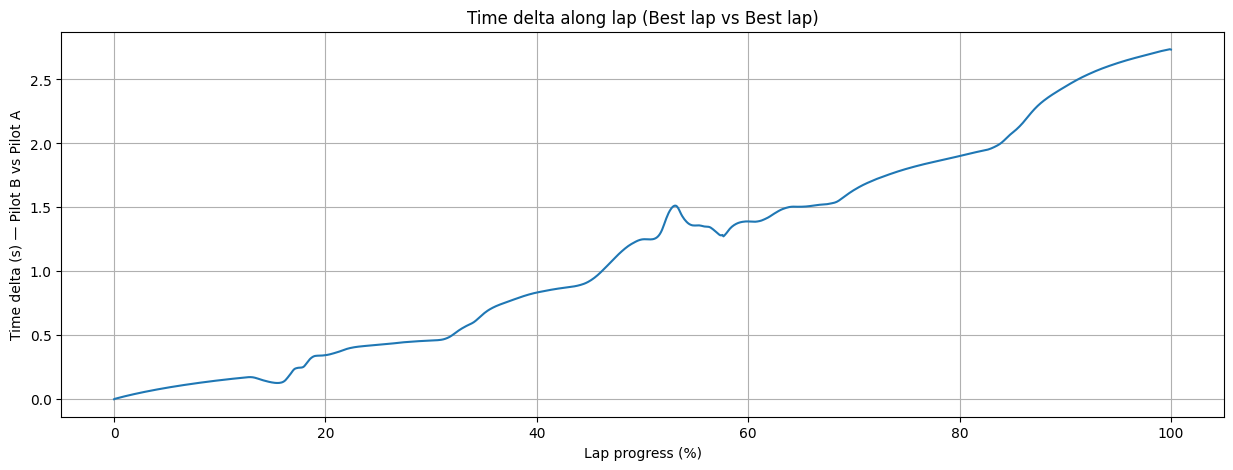

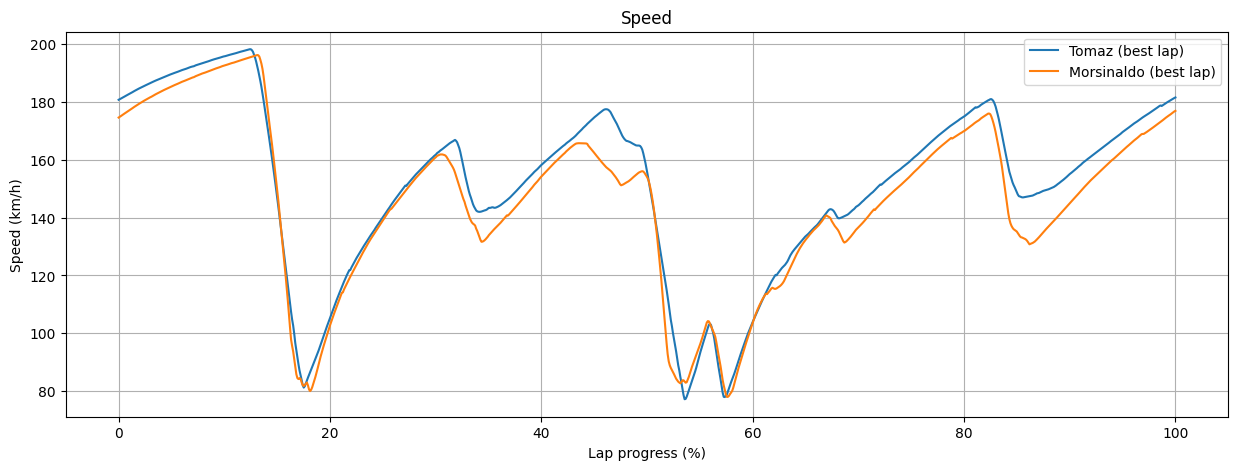

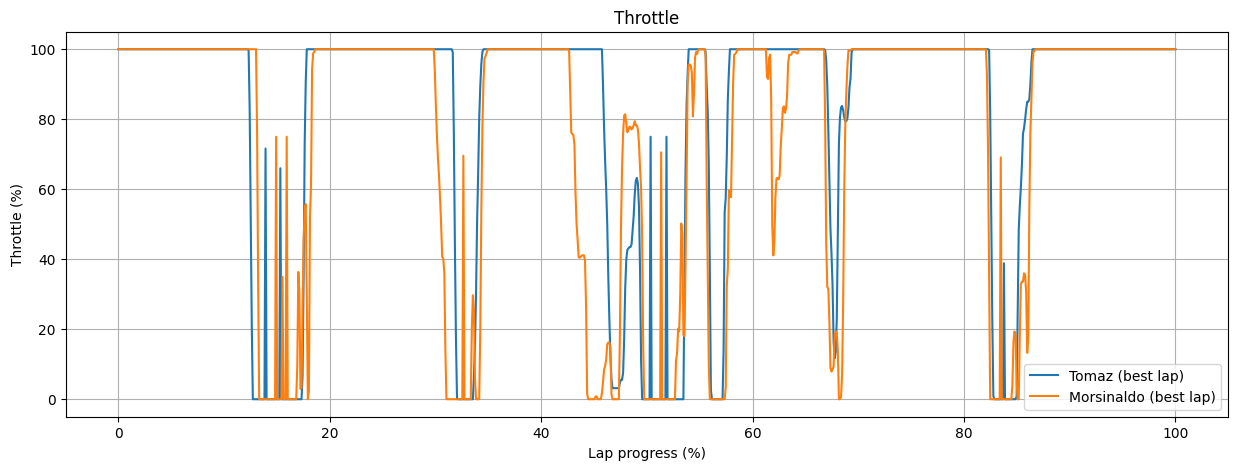

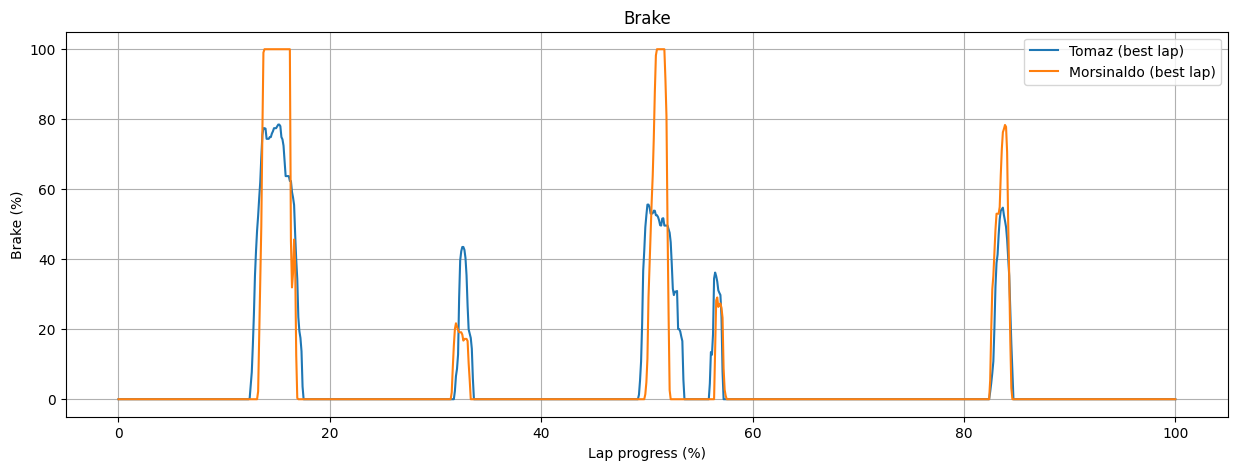

In [134]:
# --- Piloto A ---
lap_df_A = build_lap_validity_table(tomaz_df)
best_row_A = lap_df_A[lap_df_A["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_A = int(best_row_A["Lap"])

# --- Piloto B ---
lap_df_B = build_lap_validity_table(morsinaldo_df)
best_row_B = lap_df_B[lap_df_B["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_B = int(best_row_B["Lap"])

print(f"Piloto A - Best lap: {best_lap_A} ({format_laptime(best_row_A['LapTime_s'])})")
print(f"Piloto B - Best lap: {best_lap_B} ({format_laptime(best_row_B['LapTime_s'])})")

# Alinhamento por distância
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

g_A = tomaz_df[tomaz_df["Lap"] == best_lap_A]
g_B = morsinaldo_df[morsinaldo_df["Lap"] == best_lap_B]

interp_A = align_lap_by_dist(g_A, grid)
interp_B = align_lap_by_dist(g_B, grid)


# Time-loss curve (target vs reference)
time_loss = interp_B["t_rel"] - interp_A["t_rel"]

plt.figure(figsize=(15, 5))
plt.plot(grid * 100.0, time_loss)
plt.xlabel("Lap progress (%)")
plt.ylabel("Time delta (s) — Pilot B vs Pilot A")
plt.title("Time delta along lap (Best lap vs Best lap)")
plt.grid(True)
plt.show()

def quick_plot(yA, yB, label, ylab):
    plt.figure(figsize=(15, 5))
    plt.plot(grid * 100.0, yA, label="Tomaz (best lap)")
    plt.plot(grid * 100.0, yB, label="Morsinaldo (best lap)")
    plt.xlabel("Lap progress (%)")
    plt.ylabel(ylab)
    plt.title(label)
    plt.legend()
    plt.grid(True)
    plt.show()

quick_plot(interp_A["speed"],    interp_B["speed"],    "Speed",    "Speed (km/h)")
quick_plot(interp_A["throttle"], interp_B["throttle"], "Throttle", "Throttle (%)")
quick_plot(interp_A["brake"],    interp_B["brake"],    "Brake",    "Brake (%)")




## 6. Sectorization and per-sector analysis



In [135]:
def sector_slices_by_edges(lap_dist_pct: np.ndarray, edges: list) -> list:
    """
    Divide a volta em fatias (slices) baseadas nos marcos geográficos CUSTOM_EDGES.
    """
    slices = []
    for i in range(len(edges) - 1):
        # Encontra os índices onde a distância da volta está entre as bordas do setor
        mask = (lap_dist_pct >= edges[i]) & (lap_dist_pct < edges[i+1])
        
        # Garante que o último ponto (1.0) seja incluído no último setor
        if i == len(edges) - 2:
            mask = (lap_dist_pct >= edges[i]) & (lap_dist_pct <= edges[i+1])
            
        indices = np.flatnonzero(mask)
        if indices.size > 0:
            slices.append(slice(indices[0], indices[-1] + 1))
        else:
            slices.append(slice(0, 0)) # Setor vazio (segurança)
    return slices

def sector_analysis(lap_A, lap_B, edges=CUSTOM_EDGES, label_A="A", label_B="B"):
    """
    Versão atualizada para comparar performance por Curvas Reais.
    """
    lap_dist = lap_A["LapDistPct"]
    slices = sector_slices_by_edges(lap_dist, edges)
    rows = []

    for i, sl in enumerate(slices, start=1):
        if sl.start == sl.stop: continue # Pula setores sem dados
        
        a, b = sl.start, sl.stop - 1
        time_A = float(lap_A["t_rel"][b] - lap_A["t_rel"][a])
        time_B = float(lap_B["t_rel"][b] - lap_B["t_rel"][a])

        rows.append({
            "Sector": i,
            "Turn": SECTOR_NAMES.get(i, f"S{i}"),
            "DeltaTime_s": time_B - time_A,
            "MeanSpeedDiff_kph": float(np.nanmean(lap_B["speed"][sl] - lap_A["speed"][sl])),
            "MeanBrakeDiff_pct": float(np.nanmean(lap_B["brake"][sl] - lap_A["brake"][sl]))
        })
    return pd.DataFrame(rows)

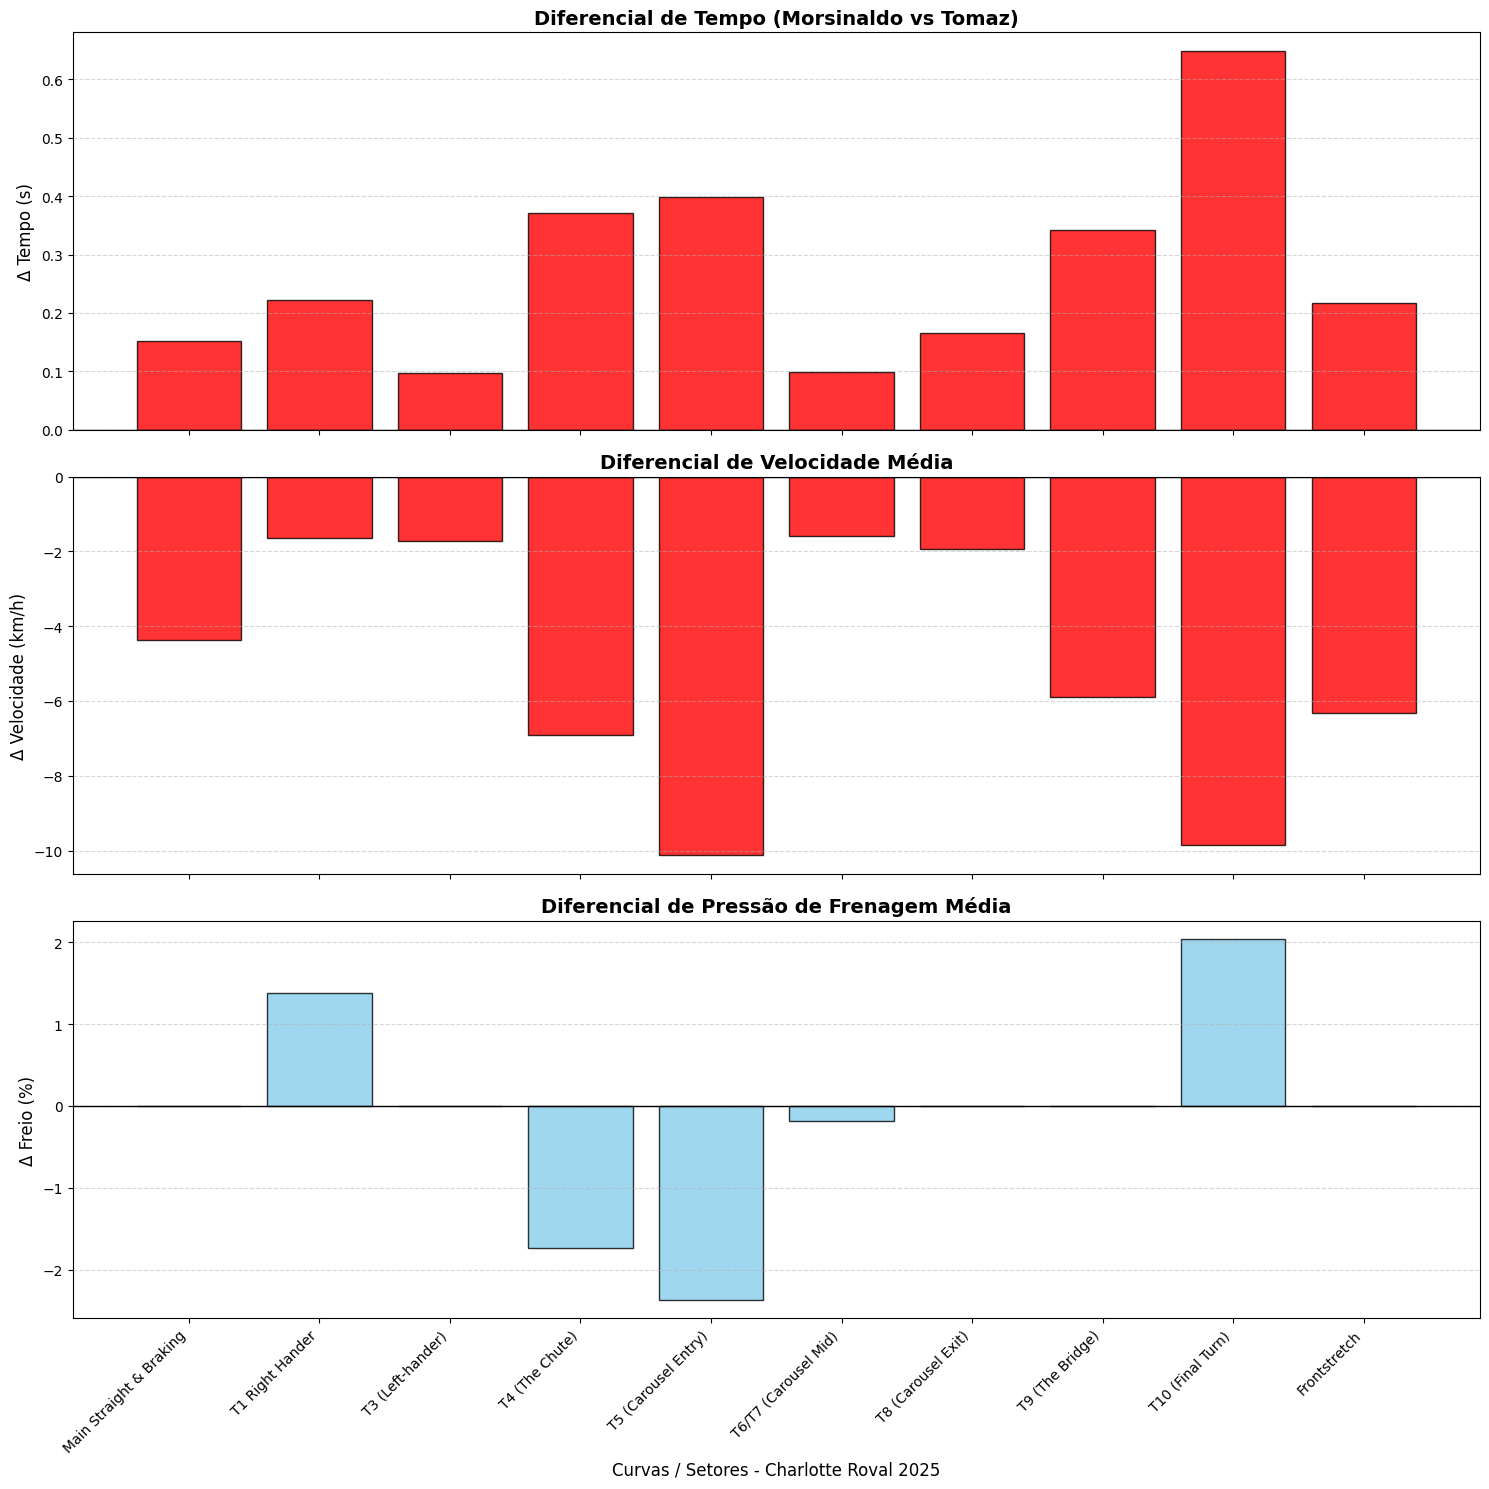

In [136]:
import matplotlib.pyplot as plt

# 1. Definimos os marcos geográficos em vez de um número fixo de setores
# Nota: N_SECTORS não é mais necessário aqui, pois usamos a lista de edges.
edges_roval = CUSTOM_EDGES 

# 2. Executamos a análise usando a nova função que aceita marcos customizados
sectors_AB = sector_analysis(
    interp_A,
    interp_B,
    edges=edges_roval,
    label_A=driver_a,
    label_B="driver_b",
)

# 3. Adicionamos os nomes das curvas para facilitar a leitura no seu relatório
sectors_AB["Turn"] = sectors_AB["Sector"].map(SECTOR_NAMES)

# 4. Reorganizamos as colunas para colocar o nome da curva em evidência
cols = ["Sector", "Turn", "DeltaTime_s", "MeanSpeedDiff_kph", "MeanBrakeDiff_pct"]
sectors_AB = sectors_AB[cols]

sectors_AB

# 1. Preparação dos dados (garantir que a coluna 'Turn' existe e está ordenada)
if "Turn" not in sectors_AB.columns:
    sectors_AB["Turn"] = sectors_AB["Sector"].map(SECTOR_NAMES)
df_plot = sectors_AB.sort_values("Sector")

# 2. Configuração da figura com 3 subplots verticais
fig, ax = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

# --- Gráfico 1: Delta de Tempo ---
# Vermelho: Morsinaldo perde tempo (Delta > 0) | Verde: Morsinaldo ganha tempo (Delta < 0)
colors_time = ['red' if x > 0 else 'green' for x in df_plot["DeltaTime_s"]]
ax[0].bar(df_plot["Turn"], df_plot["DeltaTime_s"], color=colors_time, edgecolor='black', alpha=0.8)
ax[0].set_ylabel("Δ Tempo (s)", fontsize=12)
ax[0].set_title("Diferencial de Tempo (Morsinaldo vs Tomaz)", fontsize=14, fontweight='bold')
ax[0].axhline(0, color="black", linewidth=1)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Gráfico 2: Delta de Velocidade Média ---
# Verde: Morsinaldo mais rápido (Diff > 0) | Vermelho: Morsinaldo mais lento (Diff < 0)
colors_speed = ['green' if x > 0 else 'red' for x in df_plot["MeanSpeedDiff_kph"]]
ax[1].bar(df_plot["Turn"], df_plot["MeanSpeedDiff_kph"], color=colors_speed, edgecolor='black', alpha=0.8)
ax[1].set_ylabel("Δ Velocidade (km/h)", fontsize=12)
ax[1].set_title("Diferencial de Velocidade Média", fontsize=14, fontweight='bold')
ax[1].axhline(0, color="black", linewidth=1)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- Gráfico 3: Delta de Pressão de Freio ---
# Azul/Ciano para representar intensidade de freio
ax[2].bar(df_plot["Turn"], df_plot["MeanBrakeDiff_pct"], color='skyblue', edgecolor='black', alpha=0.8)
ax[2].set_ylabel("Δ Freio (%)", fontsize=12)
ax[2].set_title("Diferencial de Pressão de Frenagem Média", fontsize=14, fontweight='bold')
ax[2].axhline(0, color="black", linewidth=1)
ax[2].grid(axis='y', linestyle='--', alpha=0.5)

# Ajustes finais dos eixos
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel("Curvas / Setores - Charlotte Roval 2025", fontsize=12)

# Adiciona um pequeno padding para as legendas não cortarem
plt.tight_layout()
plt.show()


## New Heuristics



## Base Functions 

In [137]:
from scipy.signal import savgol_filter
from typing import List

# --- Funções de Cálculo de Heurísticas (DNA) ---

def compute_derivatives(sec: dict):
    t = sec["t_rel"]
    # dt robusto para dados com pequena variação de amostragem
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.01 

    brake = sec["brake"]
    throttle = sec["throttle"]

    # Cálculo da taxa de variação (Ramp Rates)
    brake_rate = np.gradient(brake, dt)
    throttle_rate = np.gradient(throttle, dt)

    # Suavização para remover ruído de sensor/input
    window = min(9, len(brake_rate))
    if window > 3 and window % 2 != 0:
        brake_rate = savgol_filter(brake_rate, window, 3)
        throttle_rate = savgol_filter(throttle_rate, window, 3)

    return brake_rate, throttle_rate

def braking_heuristics(sec: dict, brake_rate):
    d = {}
    brake_mask = sec["brake"] > 0.05
    if np.any(brake_mask):
        d["BrakeRampRate"] = float(np.quantile(brake_rate[brake_mask], 0.95))
        d["BrakeConsistency"] = float(np.var(brake_rate[brake_mask]))
        d["BrakeEfficiency"] = float(abs(np.min(sec["long_accel"][brake_mask])) / 
                                     (np.max(sec["brake"][brake_mask]) + 1e-6))
    else:
        d["BrakeRampRate"], d["BrakeConsistency"], d["BrakeEfficiency"] = 0.0, 0.0, 0.0
    return d

def rotation_heuristics(sec: dict):
    d = {}
    speed = sec["speed"]
    yaw = sec["yaw_rate"]
    steer = sec["steering"]
    t = sec["t_rel"]

    idx_vmin = np.argmin(speed)
    idx_mrp = np.argmax(np.abs(yaw))

    d["Vmin"] = float(speed[idx_vmin])
    d["Delta_MRP_Vmin"] = float(t[idx_vmin] - t[idx_mrp])
    
    # --- INJETADO: Trail Braking Overlap ---
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.01
    d["TrailOverlap"] = float((sec["brake"] * np.abs(steer) * dt).sum())
    
    # --- INJETADO: Vmin Normalizado (Eficiência de entrada) ---
    d["Vmin_Norm"] = float(d["Vmin"] / (speed[0] + 1e-6))

    avg_steer = np.mean(np.abs(steer))
    d["RotationEfficiency"] = float(np.mean(np.abs(yaw)) / (avg_steer + 1e-6)) if avg_steer > 1e-3 else 0.0
    return d

def acceleration_heuristics(sec: dict, throttle_rate):
    d = {}
    throttle_mask = sec["throttle"] > 0.05
    if np.any(throttle_mask):
        d["ThrottleAttackRate"] = float(np.quantile(throttle_rate[throttle_mask], 0.95))
        d["ThrottleSmoothness"] = float(1.0 / (np.var(throttle_rate[throttle_mask]) + 1e-6))
        d["ThrottleSteerConflict"] = float(np.mean(sec["throttle"] * np.abs(sec["steering"])))
        
        # --- INJETADO: Eficiência Longitudinal (G's por acelerador) ---
        d["AccelEfficiency"] = float(np.mean(sec["long_accel"][throttle_mask]) / 
                                     (np.mean(sec["throttle"][throttle_mask]) + 1e-6))
    else:
        d["ThrottleAttackRate"], d["ThrottleSmoothness"], d["ThrottleSteerConflict"], d["AccelEfficiency"] = 0.0, 0.0, 0.0, 0.0
    return d

def sector_heuristics(sec_raw: dict) -> dict:
    """Mapeia os canais brutos para o dicionário de heurísticas com métricas de memória."""
    sec = {
        "t_rel": sec_raw["t_rel"],
        "speed": sec_raw["speed"],
        "brake": sec_raw["brake"],
        "throttle": sec_raw["throttle"],
        "steering": sec_raw["SteeringWheelAngle"],
        "yaw_rate": sec_raw["YawRate"],
        "long_accel": sec_raw.get("LongAccel", np.zeros_like(sec_raw["speed"])),
    }

    brake_rate, throttle_rate = compute_derivatives(sec)

    # 1. Definimos as métricas de "fronteira" do setor (Essencial para o Legado)
    h = {
        "SpeedStart": float(sec["speed"][0]),
        "SpeedEnd": float(sec["speed"][-1]),
        "BrakePeak": float(np.max(sec["brake"])),  # Da sua função antiga
        "SteerRMS": float(np.sqrt(np.mean((sec["steering"])**2))) # Mede agressividade/sawing
    }

    # 2. Atualizamos com as heurísticas comportamentais
    h.update(braking_heuristics(sec, brake_rate))
    h.update(rotation_heuristics(sec))
    h.update(acceleration_heuristics(sec, throttle_rate))
    
    return h

# --- Função Principal Atualizada para ROval 2025 ---

def compute_sector_heuristics(interp, edges=CUSTOM_EDGES) -> pd.DataFrame:
    """
    Processa dados de telemetria (Dict ou DataFrame) corrigindo erros de ambiguidade
    e padronizando nomes de canais para o Doutorado.
    """
    # 1. Correção do erro de ambiguidade (The truth value of a DataFrame is ambiguous)
    if interp is None: return pd.DataFrame()
    if isinstance(interp, pd.DataFrame):
        if interp.empty: return pd.DataFrame()
    elif not interp: # Caso seja dicionário
        return pd.DataFrame()

    # 2. Padronização: se for DataFrame, precisamos garantir os nomes das colunas
    if isinstance(interp, pd.DataFrame):
        # Mapeia os nomes brutos do iRacing para os nomes que suas heurísticas usam
        mapping = {
            'Speed_KPH': 'speed', 
            'Throttle_Pct': 'throttle', 
            'Brake_Pct': 'brake',
            'SessionTime': 't_rel'
        }
        # Cria um dicionário de arrays para manter a lógica igual ao dicionário da 'interp'
        data_source = {mapping.get(c, c): interp[c].values for c in interp.columns}
        lap_dist = interp["LapDistPct"].values
    else:
        # Se já for o dicionário da align_lap_by_dist, usamos direto
        data_source = interp
        lap_dist = interp["LapDistPct"]

    rows = []

    # 3. Processamento por Setor
    for i in range(len(edges) - 1):
        mask = (lap_dist >= edges[i]) & (lap_dist < edges[i+1])
        if i == len(edges) - 2:
            mask = (lap_dist >= edges[i]) & (lap_dist <= edges[i+1])
            
        indices = np.flatnonzero(mask)
        if indices.size == 0: continue
            
        sl = slice(indices[0], indices[-1] + 1)
        
        # Filtra os dados do setor
        sec_raw = {k: v[sl] for k, v in data_source.items()}

        # Garante que t_rel comece em 0 para este setor específico (importante para derivadas)
        if "t_rel" in sec_raw:
            sec_raw["t_rel"] = sec_raw["t_rel"] - sec_raw["t_rel"][0]

        # Chama sua função de DNA técnico (sector_heuristics)
        h = sector_heuristics(sec_raw)

        sid = i + 1
        h_row = {"Sector": sid, "Turn": SECTOR_NAMES.get(sid, f"Sector {sid}")}
        h_row.update(h)
        rows.append(h_row)

    return pd.DataFrame(rows)

## Driver A and B - Heuristics

In [138]:
# --- Piloto A (Tomaz) ---
# Substituímos n_sectors pelos marcos geográficos CUSTOM_EDGES
heur_A = compute_sector_heuristics(
    interp=interp_A,
    edges=CUSTOM_EDGES
)
heur_A.insert(0, "Pilot", "A")

# --- Piloto B (Morsinaldo) ---
heur_B = compute_sector_heuristics(
    interp=interp_B,
    edges=CUSTOM_EDGES
)
heur_B.insert(0, "Pilot", "B")

# Exibição do resumo do Piloto B para conferência das curvas de 2025
display(heur_A)

,Pilot,Sector,Turn,SpeedStart,SpeedEnd,BrakePeak,SteerRMS,BrakeRampRate,BrakeConsistency,BrakeEfficiency,Vmin,Delta_MRP_Vmin,TrailOverlap,Vmin_Norm,RotationEfficiency,ThrottleAttackRate,ThrottleSmoothness,ThrottleSteerConflict,AccelEfficiency
0,A,1,Main Straight & Braking,180.761380,196.213431,0.000000,0.010772,0.000000,0.000000,0.000000,180.761380,-1.443143,0.000000,1.000000,0.882829,0.000000,1000000.000000,0.933770,0.006355
1,A,2,T1 Right Hander,196.312144,118.655341,78.468584,0.724270,82.244864,1933.652663,0.148176,81.230326,0.139880,50.170563,0.413781,0.478440,171.800368,0.000167,28.830655,0.014416
2,A,3,T3 (Left-hander),119.480335,165.981542,0.000000,0.125610,0.000000,0.000000,0.000000,119.480335,-1.907372,0.000000,1.000000,0.831321,0.000000,1000000.000000,9.188556,0.016447
3,A,4,T4 (The Chute),166.209289,161.298629,43.498200,0.342260,107.461360,4355.505830,0.157206,142.002190,-0.795978,8.292020,0.854358,0.734544,160.188392,0.000134,19.410303,0.012487
4,A,5,T5 (Carousel Entry),161.661312,156.991632,52.573210,0.367892,140.812862,1467.816955,0.145260,156.991632,0.908248,1.069423,0.971114,0.601112,67.806533,0.000218,11.972185,0.000928
5,A,6,T6/T7 (Carousel Mid),154.997486,88.252528,55.606133,1.062354,46.374349,634.769733,0.163467,77.202798,0.440725,86.866397,0.498091,0.476936,155.854028,0.000147,42.815568,0.020206
6,A,7,T8 (Carousel Exit),89.408166,141.668741,0.000000,0.562495,0.000000,0.000000,0.000000,89.408166,-5.394892,0.000000,1.000000,0.731383,0.000000,0.074587,51.951803,0.022389
7,A,8,T9 (The Bridge),142.164962,169.585036,0.000000,0.264612,0.000000,0.000000,0.000000,139.758958,-0.082482,0.000000,0.983076,0.793547,56.727716,0.000329,15.957139,0.013931
8,A,9,T10 (Final Turn),169.905540,159.649159,54.732202,0.515414,103.683849,5530.465718,0.143745,146.999269,-1.554241,8.690636,0.865182,0.475555,59.086845,0.000225,26.020763,0.009964
9,A,10,Frontstretch,159.957322,181.558960,0.000000,0.015992,0.000000,0.000000,0.000000,159.957322,-0.784798,0.000000,1.000000,0.920959,0.000000,1000000.000000,1.408232,0.010500


# Feature Engineering

Esta seção implementa um pipeline de *coaching* baseado em regras para comparar duas voltas (A como referência e B como piloto avaliado) **por setor**. O objetivo é transformar séries temporais brutas (speed, brake, throttle, steering, yaw, RPM e gear) em:

1. **Estados interpretáveis** ao longo da volta (BRAKING, CORNER, EXIT, STRAIGHT).
2. **Métricas agregadas** por (Setor, Estado), permitindo comparação entre A e B.
3. **Deltas (B − A)** por métrica, para localizar onde o piloto perde tempo.
4. **Regras de feedback** que geram dicas curtas e acionáveis, com contexto de *onde* e *que tipo de curva* é.

A ideia central é reduzir a complexidade do sinal contínuo para um conjunto pequeno de indicadores por fase de pilotagem, o que facilita feedback para pilotos iniciantes e permite evolução incremental das regras ao longo do tempo.

## Utilitários de índice (primeiro e último evento)

Antes de extrair eventos (por exemplo, início e fim de frenagem), usamos dois utilitários simples:

- `_first_idx(mask)`: retorna o primeiro índice onde uma condição booleana é verdadeira.
- `_last_idx(mask)`: retorna o último índice onde uma condição booleana é verdadeira.

Essas funções são úteis para detectar “janelas de evento” em sinais contínuos, como:
- intervalo em que o freio está acima de um threshold;
- intervalo em que o throttle está acima de um threshold após o ápice;
- overlap entre freio e acelerador.

Esse padrão evita lógica repetida e padroniza o comportamento quando o evento não existe (retorna `None`).

In [139]:
def _first_idx(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    return int(idx[0]) if idx.size else None

def _last_idx(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    return int(idx[-1]) if idx.size else None

## Rotulagem de estados (BRAKING, CORNER, EXIT, STRAIGHT)

Para gerar dicas por fase, primeiro precisamos “entender” o que o carro está fazendo ao longo do tempo. A função `label_state_df` recebe um DataFrame com sinais normalizados em percentual e devolve um vetor de estados:

- **BRAKING**: freio acima do threshold.
- **CORNER**: lateralidade alta (steering e opcionalmente yaw), independentemente do throttle.
- **EXIT**: throttle alto **e** lateralidade baixa (carro já está alinhado).
- **STRAIGHT**: restante.

A ordem de prioridade é importante:

1. **BRAKING tem prioridade máxima**, porque durante a frenagem o comportamento é dominado pela desaceleração e estabilidade.
2. **CORNER vem em seguida**, para capturar curvas “flat-out” (throttle alto com volante carregado).
3. **EXIT só ocorre quando o carro está alinhado**, ou seja, throttle alto com baixa lateralidade, representando retomada na saída.
4. O que sobra vira **STRAIGHT**.

Esse esquema evita confundir “aceleração em curva” com “saída da curva” e produz estados mais coerentes para coaching.

In [140]:
import numpy as np
import pandas as pd

## Não utilizado nesta análise, mas mantido para referência futura ##
def label_state_df(
    g: pd.DataFrame,
    brake_th: float = 15.0,
    throttle_th: float = 60.0,
    steer_th: float = 1.0,        # 👈 menor
    latacc_th: float = 0.6,       # g lateral
    window: int = 15              # suavização
):
    """
    Estados:
    BRAKING / CORNER / EXIT / STRAIGHT

    Filosofia:
    - CORNER = lateral sustentada (não pico de volante)
    - EXIT = transição curta pós-curva
    - STRAIGHT = WOT estável
    """

    brake = g["Brake_Pct"].to_numpy()
    throttle = g["Throttle_Pct"].to_numpy()
    speed = g["Speed_KPH"].to_numpy()
    steer = g["SteeringWheelAngle"].to_numpy()

    latacc = (
        g["LatAccel"].to_numpy()
        if "LatAccel" in g.columns
        else np.zeros(len(g))
    )

    n = len(g)
    state = np.array(["STRAIGHT"] * n, dtype=object)

    # =========================
    # 1) BRAKING
    # =========================
    braking = brake > brake_th
    state[braking] = "BRAKING"

    # =========================
    # 2) CORNER (lateral sustentada)
    # =========================
    steer_rms = pd.Series(steer).rolling(
        window, center=True, min_periods=5
    ).std().to_numpy()

    lateral = (
        (np.abs(latacc) > latacc_th) |
        (steer_rms > steer_th)
    )

    corner = lateral & (~braking)
    state[corner] = "CORNER"

    # =========================
    # 3) EXIT (curta transição)
    # =========================
    d_speed = np.gradient(speed)

    exit_mask = (
        (throttle > throttle_th) &
        (~braking) &
        (~corner) &
        (d_speed > 0.05)
    )

    state[exit_mask] = "EXIT"

    # =========================
    # 4) STRAIGHT (estável)
    # =========================
    straight = (
        (throttle > 90) &
        (~braking) &
        (~corner) &
        (steer_rms < steer_th * 0.6) &
        (np.abs(latacc) < latacc_th * 0.7)
    )

    return pd.Series(state, index=g.index, name="State")


## Agregação por (Setor, Estado)

Após rotular cada amostra com um estado, a função `summarize_by_sector_and_state` transforma a volta em uma tabela agregada. O procedimento é:

1. **Divide a volta em setores** usando `LapDistPct` em intervalos uniformes (ex.: 4 setores por quartis).
2. **Cria um DataFrame temporário (`gtmp`)** com as colunas exigidas por `label_state_df`, reaproveitando a mesma assinatura.
3. **Gera o vetor de estados** para cada amostra.
4. **Segmenta trechos contínuos** com o mesmo estado (runs).  
   - Isso evita misturar momentos diferentes da pilotagem dentro do mesmo estado.
   - `min_len` remove segmentos muito curtos, que tendem a ser ruído de limiar.
5. Para cada segmento válido, calcula métricas relevantes e monta linhas “por trecho”.
6. Por fim, agrega (groupby) por **(Sector, State)** para obter uma tabela compacta por volta.

O resultado é uma tabela que representa “como foi a pilotagem em cada setor e em cada fase”, pronta para comparação entre A e B.

In [141]:
import numpy as np
import pandas as pd
from collections import Counter


def summarize_by_sector_and_state(interp: dict, edges=CUSTOM_EDGES, min_len=5):
    """
    Agrupa a telemetria por Curvas Reais e Estados de Condução.
    """
    # 1. Extração de dados
    lap = interp["LapDistPct"]
    speed = interp["speed"]
    brake = interp["brake"]
    throttle = interp["throttle"]
    steer = interp.get("SteeringWheelAngle", np.zeros_like(speed))
    yaw = interp.get("YawRate", np.zeros_like(speed))
    gear = interp.get("Gear", np.zeros_like(speed))
    latacc = interp.get("LatAccel", np.zeros_like(speed))

    # 2. Setorização por Marcos Geográficos (Curvas)
    sector = np.clip(np.digitize(lap, edges, right=True), 1, len(edges)-1)

    # 3. Classificação de Estados
    gtmp = pd.DataFrame({
        "Brake_Pct": brake, "Throttle_Pct": throttle,
        "Speed_KPH": speed, "LatAccel": latacc, "SteeringWheelAngle": steer
    })
    # Usa a sua função label_state_df definida anteriormente
    state = label_state_df(gtmp).to_numpy()

    def segment_runs(vals):
        runs = []
        n = len(vals); i = 0
        while i < n:
            j = i + 1
            while j < n and vals[j] == vals[i]: j += 1
            runs.append((i, j, vals[i]))
            i = j
        return runs

    def _mode_int(arr):
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0: return np.nan
        c = Counter(arr.astype(int).tolist())
        return float(c.most_common(1)[0][0])

    # 4. Processamento de Heurísticas
    rows = []
    for a, b, lab in segment_runs(state):
        if (b - a) < min_len: continue

        sid = int(Counter(sector[a:b].tolist()).most_common(1)[0][0])
        
        row = {
            "Sector": sid, "State": lab, "Len": int(b - a),
            "SpeedMean": float(np.mean(speed[a:b])),
            "Vmin": float(np.min(speed[a:b])),
            "ThrottleMean": float(np.mean(throttle[a:b])),
            "BrakePeak": float(np.max(brake[a:b])),
            "SteerRMS": float(np.sqrt(np.mean((steer[a:b])**2))),
            "EntrySpeed": float(speed[a]) # Velocidade no início do estado
        }
        rows.append(row)

    seg_df = pd.DataFrame(rows)
    if seg_df.empty: return seg_df

    # 5. Agregação Final
    agg = seg_df.groupby(["Sector", "State"], as_index=False).mean()
    return agg

def generate_dna_comparison(df_a, df_b):
    """
    Cria a tabela comparativa de DNA de Pilotagem com nomes de curvas.
    """
    # Merge das tabelas dos dois pilotos
    m = pd.merge(df_a, df_b, on=["Sector", "State"], suffixes=("_A", "_B"))
    
    # Adiciona nomes das curvas
    m["Turn_Name"] = m["Sector"].map(SECTOR_NAMES)
    
    # Lista de heurísticas para comparar
    metrics = ["Vmin", "BrakePeak", "EntrySpeed", "SteerRMS"]
    
    for col in metrics:
        if f"{col}_A" in m.columns and f"{col}_B" in m.columns:
            m[f"Delta_{col}"] = m[f"{col}_B"] - m[f"{col}_A"]

    # Reorganiza colunas para o relatório
    cols = ["Sector", "Turn_Name", "State"] + [f"Delta_{c}" for c in metrics]
    return m[cols].sort_values(by=["Sector", "State"])

In [142]:
def compare_pilot_heuristics_per_turn(heur_A, heur_B):
    """
    Une as heurísticas dos dois pilotos em uma única tabela de 18 linhas,
    calculando os deltas técnicos para cada curva.
    """
    # 1. Merge das tabelas (A e B já calculadas por compute_sector_heuristics)
    # Cada tabela já possui 18 linhas (uma por curva do Roval 2025)
    m = pd.merge(heur_A, heur_B, on=["Sector", "Turn"], suffixes=("_A", "_B"))
    
    # 2. Identifica automaticamente as colunas de métricas para calcular Delta
    # Remove colunas de identificação
    excluded = ["Pilot_A", "Pilot_B", "Sector", "Turn"]
    metrics = [c.replace("_A", "") for c in m.columns if c.endswith("_A") and c not in excluded]
    
    for col in metrics:
        col_a = f"{col}_A"
        col_b = f"{col}_B"
        # Delta = Morsinaldo (B) - Tomaz (A)
        m[f"Δ_{col}"] = m[col_b] - m[col_a]
        
    return m.sort_values("Sector")

# --- EXECUÇÃO ---
# 1. Calcula as heurísticas completas para os 18 setores
hA = compute_sector_heuristics(interp_A, edges=CUSTOM_EDGES)
hB = compute_sector_heuristics(interp_B, edges=CUSTOM_EDGES)

# 2. Gera a comparação final (Sem a divisão por estados)
dna_turns = compare_pilot_heuristics_per_turn(hA, hB)

# 3. Exibição
display(dna_turns.head())

,Sector,Turn,SpeedStart_A,SpeedEnd_A,BrakePeak_A,SteerRMS_A,BrakeRampRate_A,BrakeConsistency_A,BrakeEfficiency_A,Vmin_A,...,Δ_BrakeEfficiency,Δ_Vmin,Δ_Delta_MRP_Vmin,Δ_TrailOverlap,Δ_Vmin_Norm,Δ_RotationEfficiency,Δ_ThrottleAttackRate,Δ_ThrottleSmoothness,Δ_ThrottleSteerConflict,Δ_AccelEfficiency
0,1,Main Straight & Braking,180.761380,196.213431,0.000000,0.010772,0.000000,0.000000,0.000000,180.761380,...,0.000000,-6.148883,-3.103153,0.000000,-1.948118e-10,-0.061045,0.000000,0.000000,-0.392603,0.001178
1,2,T1 Right Hander,196.312144,118.655341,78.468584,0.724270,82.244864,1933.652663,0.148176,81.230326,...,-0.012175,-1.211283,0.842253,-16.668828,4.026378e-04,0.045798,-70.400182,0.000036,-9.019075,-0.002847
2,3,T3 (Left-hander),119.480335,165.981542,0.000000,0.125610,0.000000,0.000000,0.000000,119.480335,...,0.000000,-2.835451,-0.641975,0.000000,-2.034510e-10,0.019631,0.000000,-999999.998940,-1.371244,0.000793
3,4,T4 (The Chute),166.209289,161.298629,43.498200,0.342260,107.461360,4355.505830,0.157206,142.002190,...,0.051928,-10.351791,0.969935,-4.348372,-2.102734e-02,0.174110,-48.464582,0.000192,-6.054617,0.002278
4,5,T5 (Carousel Entry),161.661312,156.991632,52.573210,0.367892,140.812862,1467.816955,0.145260,156.991632,...,0.396727,-5.805833,-0.754902,-1.058576,-1.573259e-02,0.278336,32.001304,-0.000067,-5.471162,0.003057


## Geração das tabelas agregadas (A e B)

Com `summarize_by_sector_and_state`, geramos uma tabela por volta:

- `A_seg`: volta de referência (lap A)
- `B_seg`: volta do piloto avaliado (lap B)

Cada tabela contém linhas por (Setor, Estado) e colunas com as métricas agregadas.  
Essas tabelas são a base do passo seguinte: comparar A vs B e calcular deltas.

✅ Imagem salva em: C:\Users\PC\Documents\GitHub\Racing4all\Iracing\img\setores_summit_point.png


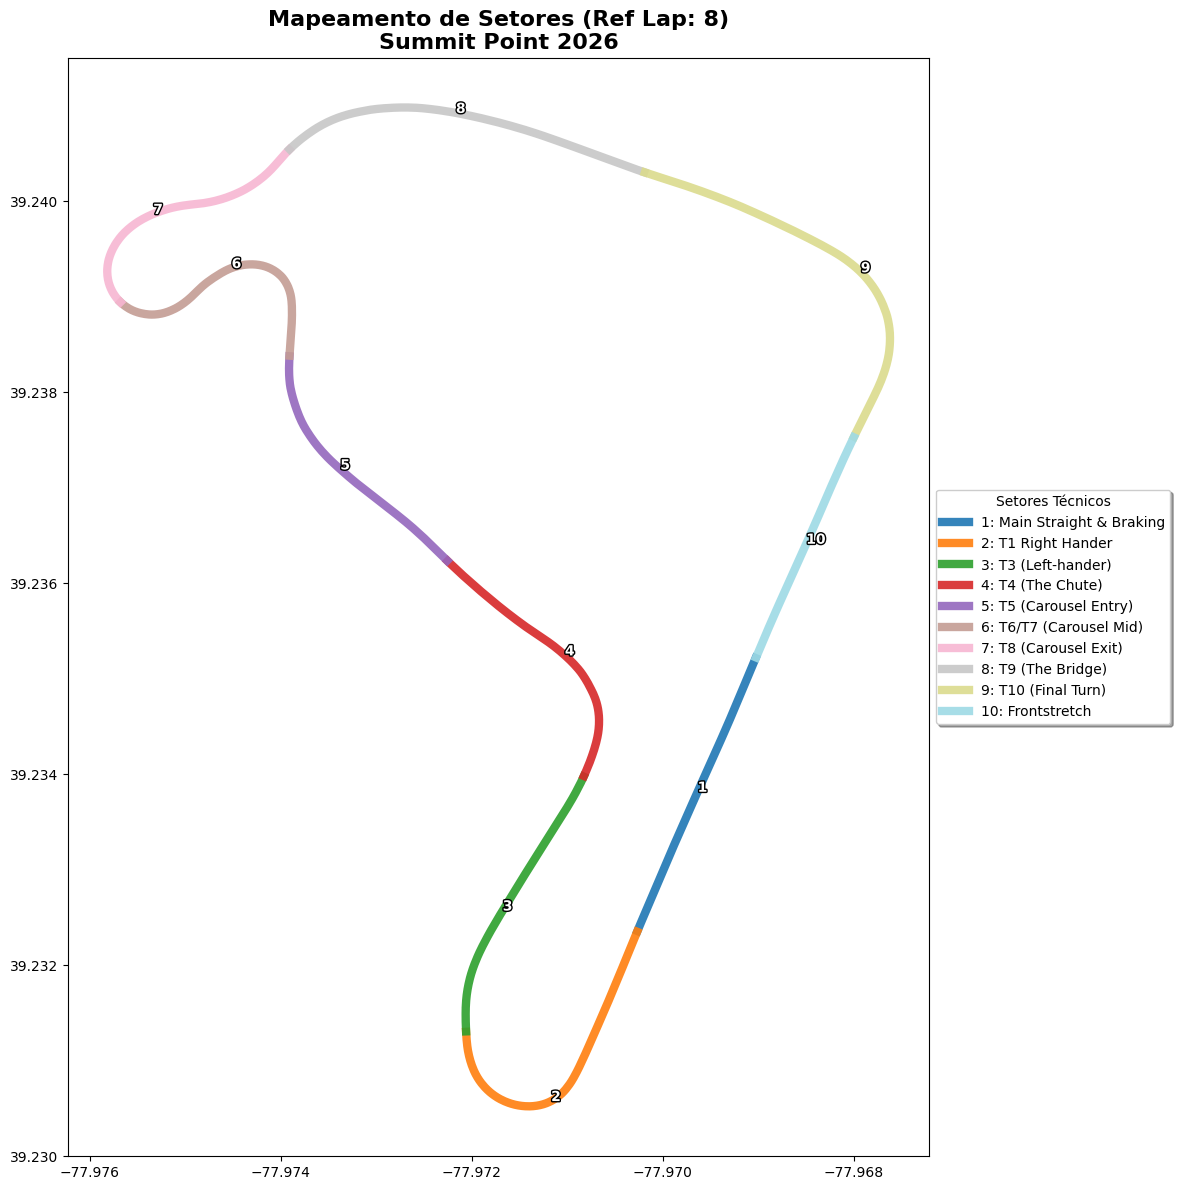

In [143]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import numpy as np
import os

def plot_and_save_sectors(df, track_name="Summit Point", edges=CUSTOM_EDGES, names=SECTOR_NAMES):
    # 1. Identificação Automática da Volta Mais Rápida
    lap_stats = df.groupby("Lap")["SessionTime"].agg(lambda x: x.max() - x.min())
    valid_laps = lap_stats[lap_stats > 30] 
    ref_lap = valid_laps.idxmin()
    
    # 2. Preparação dos Dados
    g = df[df["Lap"] == ref_lap].copy().sort_values("SessionTime")
    if g["LapDistPct"].max() > 1.5:
        g["LapDistPct"] /= 100.0
        
    g["Sector"] = np.clip(np.digitize(g["LapDistPct"], edges, right=True), 1, len(edges)-1)
    
    # 3. Configuração do Mapa
    fig, ax = plt.subplots(figsize=(15, 12))
    cmap = plt.get_cmap('tab20', len(edges)-1)
    
    for sid in sorted(g["Sector"].unique()):
        sector_data = g[g["Sector"] == sid]
        if sector_data.empty: continue
        
        ax.plot(sector_data["Lon"], sector_data["Lat"], 
                color=cmap(sid-1), lw=6, alpha=0.9, 
                label=f"{sid}: {names.get(sid, 'Setor')}")
        
        mid_idx = len(sector_data) // 2
        ax.text(sector_data["Lon"].iloc[mid_idx], sector_data["Lat"].iloc[mid_idx], 
                str(sid), fontsize=10, weight='bold', color='white',
                path_effects=[patheffects.withStroke(linewidth=2, foreground="black")])

    # 4. Estética e Título Dinâmico
    ax.set_aspect('equal')
    ax.set_title(f"Mapeamento de Setores (Ref Lap: {ref_lap})\n{track_name} 2026", 
                 fontsize=16, fontweight='bold')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Setores Técnicos", 
              fontsize=10, shadow=True, fancybox=True)
    
    plt.tight_layout()

    # 5. Lógica de Salvamento na Pasta Especificada
    save_path = r"C:\Users\PC\Documents\GitHub\Racing4all\Iracing\img"
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    filename = f"setores_{track_name.lower().replace(' ', '_')}.png"
    full_save_path = os.path.join(save_path, filename)
    
    fig.savefig(full_save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Imagem salva em: {full_save_path}")
    
    return fig, ax

# --- EXECUÇÃO PARA SUMMIT POINT ---
fig, ax = plot_and_save_sectors(tomaz_df, track_name="Summit Point")
plt.show()

## Comparação A vs B por estado e setor (deltas B − A)

A função `compare_seg_tables` faz o merge das tabelas agregadas por:

- `Sector`
- `State`

e cria colunas `Δ_*` calculadas como **B − A** para cada métrica existente.

Por que usar deltas?

- As métricas absolutas variam por carro, setup e pista.
- O delta foca no que importa para coaching: **o que mudou em relação à referência**.
- Os deltas viram “features” de regras: exemplos
  - Δ_EntrySpeed negativo → piloto entra mais lento.
  - Δ_ThrottleOn_Speed negativo → piloto retoma com velocidade menor.
  - Δ_CoastFrac positivo → piloto está “tirando pé” mais tempo.

Além das métricas agregadas, também existe espaço para incluir colunas do pipeline 1 (como BrakeRampRate etc.), quando elas estiverem disponíveis em `A_seg` e `B_seg`.

In [144]:
def generate_master_comparison(heur_A, heur_B):
    """
    Versão otimizada da compare_seg_tables para análise por curva (sem States).
    Une os pilotos A e B e calcula deltas de todas as métricas.
    """
    # 1. Cruzamento apenas por Setor e Nome da Curva
    # (Removido o "State" para bater com sua nova filosofia de análise)
    m = pd.merge(heur_A, heur_B, on=["Sector", "Turn"], suffixes=("_A", "_B"))
    
    # 2. Identifica automaticamente as métricas (tudo que termina em _A)
    # Isso evita que você tenha que listar 50 nomes de colunas manualmente
    metrics = [c.replace("_A", "") for c in m.columns if c.endswith("_A") and c not in ["Pilot_A", "Turn_A"]]
    
    for col in metrics:
        col_a, col_b = f"{col}_A", f"{col}_B"
        if col_a in m.columns and col_b in m.columns:
            # Cálculo do Delta: B (Morsinaldo) - A (Tomaz)
            m[f"Δ_{col}"] = m[col_b] - m[col_a]
            
    return m.sort_values("Sector").reset_index(drop=True)

# --- COMO USAR AGORA ---
# 1. Gere as tabelas de 18 linhas para cada piloto
hA = compute_sector_heuristics(interp_A, edges=CUSTOM_EDGES)
hB = compute_sector_heuristics(interp_B, edges=CUSTOM_EDGES)

# 2. Crie a Master Table com os Deltas
seg_cmp = generate_master_comparison(hA, hB)

# 3. Verifique a estrutura (as 55 colunas estarão lá)
seg_cmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sector                   10 non-null     int64  
 1   Turn                     10 non-null     object 
 2   SpeedStart_A             10 non-null     float64
 3   SpeedEnd_A               10 non-null     float64
 4   BrakePeak_A              10 non-null     float64
 5   SteerRMS_A               10 non-null     float64
 6   BrakeRampRate_A          10 non-null     float64
 7   BrakeConsistency_A       10 non-null     float64
 8   BrakeEfficiency_A        10 non-null     float64
 9   Vmin_A                   10 non-null     float64
 10  Delta_MRP_Vmin_A         10 non-null     float64
 11  TrailOverlap_A           10 non-null     float64
 12  Vmin_Norm_A              10 non-null     float64
 13  RotationEfficiency_A     10 non-null     float64
 14  ThrottleAttackRate_A     10 n

## Extração de eventos por setor (apex e timings)

Além da visão por estado, usamos um segundo bloco para extrair eventos “pontuais” dentro de cada setor, como:

- **Vmin**: proxy do ápice (mínima velocidade do setor).
- **brake_on / brake_off**: início/fim da janela de freio acima do threshold.
- **throttle_on**: primeiro ponto de throttle acima do threshold após o ápice.

Com esses eventos calculamos métricas temporais relativas ao ápice (Vmin), como:

- **brake_lead_vs_vmin**: quanto antes do ápice o freio começa.
- **brake_release_vs_vmin**: quanto depois/antes do ápice o freio termina.
- **throttle_delay_vs_vmin**: quanto tempo após o ápice o throttle volta.

Esse conjunto é útil para regras mais “cinemáticas” (timing), complementando as métricas agregadas por estado.

In [145]:
def sector_events(sec, brake_th=0.05, throttle_th=0.05):
    t = sec["t_rel"]
    speed = sec["speed"]
    brake = sec["brake"]
    throttle = sec["throttle"]
    lap = sec["LapDistPct"]

    idx_vmin = int(np.argmin(speed))

    # brake_on/off: primeiro e último acima do threshold (dentro do setor)
    brake_mask = brake > brake_th
    idx_brake_on = _first_idx(brake_mask)
    idx_brake_off = _last_idx(brake_mask)

    # throttle_on: primeiro throttle após o vmin
    post = np.arange(len(t)) >= idx_vmin
    idx_throttle_on = _first_idx((throttle > throttle_th) & post)

    ev = {
        "t_vmin": float(t[idx_vmin]),
        "vmin": float(speed[idx_vmin]),
        "lap_vmin": float(lap[idx_vmin]) if lap is not None else None,

        "t_brake_on": float(t[idx_brake_on]) if idx_brake_on is not None else None,
        "t_brake_off": float(t[idx_brake_off]) if idx_brake_off is not None else None,

        "t_throttle_on": float(t[idx_throttle_on]) if idx_throttle_on is not None else None,
    }

    # relações ao apex (Vmin)
    ev["brake_lead_vs_vmin"] = (ev["t_vmin"] - ev["t_brake_on"]) if ev["t_brake_on"] is not None else None
    ev["throttle_delay_vs_vmin"] = (ev["t_throttle_on"] - ev["t_vmin"]) if ev["t_throttle_on"] is not None else None
    ev["brake_release_vs_vmin"] = (ev["t_brake_off"] - ev["t_vmin"]) if ev["t_brake_off"] is not None else None

    return ev

def compute_sector_events_table(interp, edges=CUSTOM_EDGES):
    """
    Versão atualizada: Extrai o TIMING de cada ação para as 18 curvas reais.
    """
    lap_dist = interp["LapDistPct"]
    rows = []
    
    # Criamos as fatias baseadas nos marcos geográficos das curvas
    for i in range(len(edges) - 1):
        mask = (lap_dist >= edges[i]) & (lap_dist < edges[i+1])
        if i == len(edges) - 2:
            mask = (lap_dist >= edges[i]) & (lap_dist <= edges[i+1])
            
        indices = np.flatnonzero(mask)
        if indices.size == 0: continue
            
        sl = slice(indices[0], indices[-1] + 1)
        sec = {k: v[sl] for k, v in interp.items()}
        sec["LapDistPct"] = interp["LapDistPct"][sl]
        
        # Chama a função que identifica o momento exato de cada evento
        ev = sector_events(sec)

        sid = i + 1
        row = {
            "Sector": sid, 
            "Turn": SECTOR_NAMES.get(sid, f"S{sid}"),
            **ev
        }
        rows.append(row)

    return pd.DataFrame(rows)

## Tabela de eventos por setor

`compute_sector_events_table` percorre todos os setores e aplica `sector_events` para cada slice da volta.

O resultado é uma tabela por volta (A e B) com:
- posição do ápice (lap_vmin),
- timings (t_brake_on/off, t_throttle_on),
- métricas relativas ao ápice.

Depois, `compare_sector_tables` faz o merge A vs B por setor e produz `Δ_*` das métricas principais.

Essa tabela é usada para detectar padrões de “timing”, como:
- frear cedo demais,
- soltar freio tarde demais,
- voltar ao throttle tarde demais.

In [146]:
def compare_sector_timing(evA, evB, sectors_AB):
    """
    Une os eventos de timing e correlaciona com o ganho/perda de tempo.
    """
    # 1. Merge dos eventos de timing (A e B)
    # Incluímos 'Turn' no merge para manter os nomes das curvas do Roval 2025
    m = evA.merge(evB, on=["Sector", "Turn"], suffixes=("_A", "_B"))
    
    # 2. Trazemos o DeltaTime_s (a performance final de cada setor)
    m = m.merge(sectors_AB[["Sector", "DeltaTime_s"]], on="Sector", how="left")

    # 3. Cálculo dos Deltas de Timing (B - A)
    # Valores negativos em brake_lead significam que B freou mais tarde
    # Valores positivos em throttle_delay significam que B demorou mais para acelerar
    timing_metrics = ["vmin", "brake_lead_vs_vmin", "throttle_delay_vs_vmin", "brake_release_vs_vmin"]
    
    for c in timing_metrics:
        if f"{c}_A" in m.columns and f"{c}_B" in m.columns:
            m[f"Δ_{c}"] = m[f"{c}_B"] - m[f"{c}_A"]

    return m.sort_values("Sector")

# --- EXECUÇÃO ATUALIZADA ---
# Chamando as funções com CUSTOM_EDGES em vez de N_SECTORS
evA = compute_sector_events_table(interp_A, edges=CUSTOM_EDGES)
evB = compute_sector_events_table(interp_B, edges=CUSTOM_EDGES)

# Gerando a tabela comparativa de timing
ev_cmp = compare_sector_timing(evA, evB, sectors_AB)

#display(ev_cmp)

## Contexto textual da dica: posição no setor e tipo de curva (proxy)

Para que a mensagem de coaching seja mais compreensível, adicionamos um prefixo com:

1. **Setor** (S1..Sn).
2. **Posição no setor**: início, meio ou fim (derivado de LapDistPct relativo ao intervalo do setor).
3. **Tipo de curva**: reta/aberta, média ou fechada.

O tipo de curva é estimado por um proxy geométrico:
- mede picos locais de yaw e steer em uma janela “à frente” do evento,
- transforma o valor em percentil dentro de uma distribuição construída ao longo da volta,
- classifica em níveis (aberta/média/fechada).

A motivação é prática: pilotos iniciantes entendem melhor “onde” e “que tipo de curva” do que apenas uma métrica abstrata.

In [147]:
def sector_position_label(lap_pct: float, sector_id: int, edges=CUSTOM_EDGES) -> str:
    """Usa as bordas reais para definir início/meio/fim da curva."""
    if not np.isfinite(lap_pct) or sector_id > len(edges)-1:
        return "posição indefinida"
    
    s0 = edges[sector_id - 1]
    s1 = edges[sector_id]
    
    # Cálculo da posição relativa dentro da curva real
    # u = (lap_pct - s0) / (s1 - s0)
    u = (lap_pct - s0) / (s1 - s0 + 1e-12)
    
    if u < 0.33: return "entrada" # Início da curva/setor
    if u < 0.66: return "ápice"   # Meio da curva/setor
    return "saída"               # Fim da curva/setor

def peak_proxy_ahead(interp: dict, lap_pct: float, ahead_pct: float = 0.02, window_pct: float = 0.004):
    """
    Retorna o pico de curvatura e pico de steer em uma janela [lap, lap+ahead].
    - ahead_pct=0.02 => olha até +2% da volta (ótimo para pegar a curva depois da frenagem)
    """
    lap = interp.get("LapDistPct", None)
    if lap is None or not np.isfinite(lap_pct):
        return np.nan, np.nan

    lap = np.asarray(lap)

    # máscara lookahead (sem wrap-around por enquanto; suficiente pra dentro do setor)
   # Adicione o operador de módulo % 1.0 para lidar com a virada da volta
    m = (lap >= (lap_pct - window_pct) % 1.0) & (lap <= (lap_pct + ahead_pct) % 1.0)
    if not np.any(m):
        return np.nan, np.nan

    speed = np.asarray(interp.get("speed", np.nan*np.ones_like(lap)))

    # yaw proxy
    yaw_peak = np.nan
    if interp.get("YawRate", None) is not None:
        yaw = np.asarray(interp["YawRate"])
        v_ms = speed[m] / 3.6
        valid = (v_ms > 2.0) & np.isfinite(yaw[m]) & np.isfinite(v_ms)
        if np.any(valid):
            vals = np.abs(yaw[m][valid]) / (v_ms[valid] + 1e-6)
            yaw_peak = float(np.nanmax(vals))

    # steer proxy
    steer_peak = np.nan
    if interp.get("SteeringWheelAngle", None) is not None:
        steer = np.asarray(interp["SteeringWheelAngle"])
        vals = np.abs(steer[m])
        vals = vals[np.isfinite(vals)]
        if vals.size:
            steer_peak = float(np.nanmax(vals))

    return yaw_peak, steer_peak

def build_proxy_distributions(interp: dict):
    sample_pcts = np.linspace(0.01, 0.99, 250)
    yaw_vals, st_vals = [], []
    for p in sample_pcts:
        ypk, spk = peak_proxy_ahead(interp, p, ahead_pct=0.02, window_pct=0.003)
        if np.isfinite(ypk): yaw_vals.append(ypk)
        if np.isfinite(spk): st_vals.append(spk)
    return np.sort(np.asarray(yaw_vals)), np.sort(np.asarray(st_vals))

def percentile_rank(sorted_vals: np.ndarray, x: float) -> float:
    if sorted_vals.size == 0 or not np.isfinite(x):
        return np.nan
    return float(np.searchsorted(sorted_vals, x, side="right") / sorted_vals.size)

def label_from_percentile(p: float) -> str:
    if not np.isfinite(p):
        return "geometria indefinida"
    if p >= 0.80:
        return "curva fechada"
    if p >= 0.55:
        return "curva média"
    return "reta ou curva aberta"

def pick_event_lappct(row: pd.Series, state: str) -> float:
    """Escolhe o LapPct onde a dica realmente acontece (âncora do texto)."""
    if state == "EXIT":
        v = row.get("ThrottleOn_Lap_B", np.nan)
        if np.isfinite(v):
            return float(v)
    if state == "BRAKING":
        v = row.get("BrakePeak_Lap_B", np.nan)
        if np.isfinite(v):
            return float(v)
    return float(row.get("LapMid_B", np.nan))


def pick_geometry_lappct(row_dict: dict, state: str, rule_id: str = "") -> float:
    """
    Onde medir a geometria:
    - BRAKING: olhar adiante do pico de freio (pegar curva após a frenagem)
    - EXIT:
        * se a dica é de 'saída limitada' (linha/ápice), medir mais perto do miolo (LapMid)
        * se a dica é de gear/rpm, medir perto do throttle-on
    """
    if state == "BRAKING":
        p = row_dict.get("BrakePeak_Lap_B", np.nan)
        return float(p) if np.isfinite(p) else float(row_dict.get("LapMid_B", np.nan))

    if state == "EXIT":
        # para dicas de saída, a curva relevante é perto do throttle-on (saída da curva)
        p = row_dict.get("ThrottleOn_Lap_B", np.nan)
        if np.isfinite(p):
            # um pouco ANTES do throttle-on costuma pegar mais "raio" (ainda com volante)
            return float(p - 0.003)
        return float(row_dict.get("LapMid_B", np.nan))

    return float(row_dict.get("LapMid_B", np.nan))

def format_tip_prefix(interp_B: dict,
                      sector_id: int,
                      lap_event: float,
                      lap_geom: float,
                      dist_yaw: np.ndarray,
                      dist_steer: np.ndarray,
                      tip_state: str,
                      n_sectors: int = 4) -> str:

    pos = sector_position_label(lap_event, sector_id, n_sectors=n_sectors)

    # Para BRAKING/EXIT, o lookahead é essencial. Para outros, pode ser menor.
    ahead = 0.03 if tip_state == "BRAKING" else (0.02 if tip_state == "EXIT" else 0.01)

    ypk, spk = peak_proxy_ahead(interp_B, lap_geom, ahead_pct=ahead, window_pct=0.003)

    py = percentile_rank(dist_yaw, ypk)
    ps = percentile_rank(dist_steer, spk)

    # decide pelo sinal mais confiável (o que der percentil válido e maior)
    cand = [(py, "yaw"), (ps, "steer")]
    cand = [(p, src) for (p, src) in cand if np.isfinite(p)]
    if not cand:
        ctype = "geometria indefinida"
    else:
        p_best, _ = max(cand, key=lambda t: t[0])
        ctype = label_from_percentile(p_best)

    return f"Setor {sector_id} · {pos} · {ctype}: "


## Regras de coaching (`DRIVING_RULES`)

As regras são declaradas como uma lista de dicionários com:

- `id`: identificador único.
- `state`: estado ao qual a regra se aplica (BRAKING/CORNER/EXIT).
- `condition(A, B)`: lógica booleana que decide se a dica deve disparar.
- `message` ou `message_fn`: texto fixo ou texto dinâmico.
- `priority`: importância relativa para ordenar dicas.
- `group` (opcional): agrupamento para evitar múltiplas dicas redundantes sobre o mesmo fenômeno.

Exemplo de regra adicionada para piloto iniciante:
- **ENTRY_SPEED_TOO_LOW**: quando B entra significativamente mais lento que A (EntrySpeed).

Isso gera dicas com números concretos (km/h), que tendem a ser mais acionáveis para quem está começando.

### Sumário das regras atuais

Abaixo está um resumo das regras presentes no seu bloco `DRIVING_RULES`, organizadas por fase (state) e com seus gatilhos principais.

#### Entrada e frenagem (state = BRAKING)

- **ENTRY_SPEED_TOO_LOW** *(grupo: ENTRY_SPEED, prioridade 4)*  
  Dispara quando a velocidade de entrada do piloto (B) está pelo menos ~8 km/h abaixo da referência (A).  
  Objetivo: sugerir uma entrada mais carregada, com magnitude aproximada do delta em km/h.

- **ENTRY_OVER_SLOW** *(grupo: ENTRY_SPEED, prioridade 3)*  
  Dispara quando B usa pico de freio > 10% acima da referência **e ainda assim** chega no miolo mais lento (Vmin menor).  
  Objetivo: identificar “over-slow” (frear demais), com foco em reduzir pico e melhorar liberação do freio.

- **ENTRY_SPEED_TARGET** *(prioridade 2)*  
  Dispara quando B está mais lento que A na entrada (> ~3 km/h), **sem** estar freando mais forte (guardrail via BrakePeak).  
  Objetivo: dar uma recomendação conservadora de ajuste (+2 a +4 km/h) quando o problema é “timidez” e não “excesso de freio”.

- **F1_AGGRESSIVE_UNSTABLE_BRAKE** *(prioridade 3)*  
  Dispara quando, em relação à referência, B apresenta aumento relevante de *BrakeRampRate* e piora de *BrakeConsistency*.  
  Objetivo: indicar entrada de freio agressiva e pouco modulada (instabilidade na frenagem).

- **F2_CONSERVATIVE_INEFFICIENT_BRAKE** *(prioridade 2)*  
  Dispara quando B reduz *BrakeRampRate* (frenagem mais “mansa”) e piora *BrakeEfficiency*.  
  Objetivo: indicar frenagem progressiva demais e pouco eficiente.

#### Meio de curva e rotação (state = CORNER)

- **R3_ROTATION_INEFFICIENT** *(prioridade 2)*  
  Dispara quando a *RotationEfficiency* de B piora (mais volante sem retorno proporcional em rotação).  
  Objetivo: reduzir esterço “ineficiente” e correções no meio da curva.

- **R1_LATE_ROTATION** *(prioridade 2)*  
  Dispara quando B mantém Vmin um pouco maior, mas a rotação acontece tarde (Δ_MRP_Vmin maior).  
  Objetivo: alertar que a rotação está chegando atrasada em relação ao ápice, mesmo com boa Vmin.

#### Saída e tração (state = EXIT)

- **LATE_THROTTLE_LOW_SPEED** *(prioridade 3)*  
  Dispara quando B inicia aceleração cheia com velocidade significativamente menor do que A (ThrottleOn_Speed menor).  
  Objetivo: sugerir preservar velocidade no miolo e alinhar mais cedo para liberar throttle melhor.

- **LONG_GEAR_EXIT** *(prioridade 2)*  
  Dispara quando B está em marcha mais longa no throttle-on e com RPM menor do que a referência.  
  Objetivo: sugerir uma marcha a menos para motor mais cheio na retomada.

- **A2_AGGRESSIVE_THROTTLE_UNSMOOTH** *(prioridade 2)*  
  Dispara quando B aumenta *ThrottleAttackRate* e piora *ThrottleSmoothness*.  
  Objetivo: indicar aplicação de throttle agressiva e pouco progressiva.

- **A4_THROTTLE_STEER_CONFLICT** *(prioridade 3)*  
  Dispara quando B aumenta *ThrottleAttackRate* e aumenta *ThrottleSteerConflict* (throttle com volante carregado).  
  Objetivo: alertar risco de perda de tração por confiança excessiva na saída.

In [148]:
import numpy as np

# --- DICIONÁRIO MESTRE DE HEURÍSTICAS (DNA DE PILOTAGEM) ---
DRIVING_RULES = [
    # --- ROTAÇÃO ATRASADA (Usando seu Delta_MRP_Vmin) ---
    {
        "id": "R3_LATE_ROTATION",
        "category": "Rotação",
        "condition": lambda A, B: (
            # Se o delta for negativo, o MRP ocorreu DEPOIS do Vmin (Erro técnico)
            B.get("Delta_MRP_Vmin", 0) < -0.05
        ),
        "message": "Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada.",
        "priority": 1
    },

    # --- EFICIÊNCIA DE FRENAGEM ---
    {
        "id": "B3_LOW_BRAKE_EFFICIENCY",
        "category": "Frenagem",
        "condition": lambda A, B: (
            B.get("BrakeEfficiency", 0) < A.get("BrakeEfficiency", 0) * 0.85
        ),
        "message": "Frenagem Ineficiente: Muita pressão de freio para pouca desaceleração. Verifique se está travando rodas ou sobrecarregando o ABS.",
        "priority": 1
    },

    # --- TRAIL BRAKING (Nova métrica injetada) ---
    {
        "id": "R4_POOR_TRAIL_BRAKING",
        "category": "Rotação",
        "condition": lambda A, B: (
            B.get("TrailOverlap", 0) < A.get("TrailOverlap", 0) * 0.70 and
            B.get("Vmin", 0) < A.get("Vmin", 0)
        ),
        "message": "Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva.",
        "priority": 2
    },
    
    # --- GRUPO 1: MEMÓRIA E LEGADO (Causa Raiz Externa) ---
    {
        "id": "L1_EXIT_SPEED_LEGACY",
        "category": "Legado",
        "condition": lambda A, B: (
            B.get("SpeedStartDiff", 0) < -2.0 and    # Entrou no setor com déficit de velocidade
            B.get("BrakePeak", 0) < 0.05            # Não houve erro de frenagem local (ignora ruído)
        ),
        "message": (
            "Perda por Legado: o prejuízo aqui é reflexo de uma saída ruim na curva anterior. "
            "Você já iniciou este trecho com velocidade inferior à referência."
        ),
        "priority": 1
    },

    # --- GRUPO 2: ENTRADA E FRENAGEM (DNA Técnico) ---
    {
        "id": "B3_OVER_BRAKING_PEAK",
        "category": "Frenagem",
        "condition": lambda A, B: (
            B.get("BrakePeak", 0) > A.get("BrakePeak", 0) + 0.15
        ),
        "message": (
            "Pico de frenagem excessivo: você está 'ancorando' demais o carro. "
            "Tente aplicar menos pressão máxima para manter a suspensão mais estável."
        ),
        "priority": 1
    },
    {
        "id": "ENTRY_OVER_SLOW",
        "category": "Frenagem",
        "condition": lambda A, B: (
            B.get("BrakePeak", 0) > A.get("BrakePeak", 0) * 1.10 and
            (B.get("Vmin", 1) - A.get("Vmin", 1)) / (A.get("Vmin", 1) + 1e-6) < -0.03
        ),
        "message": "Over-slow na entrada: pressão demais de freio matando a velocidade de ápice (Vmin).",
        "priority": 1
    },
    {
        "id": "F1_AGGRESSIVE_UNSTABLE_BRAKE",
        "category": "Frenagem",
        "condition": lambda A, B: (
            (B.get("BrakeRampRate", 1) / (A.get("BrakeRampRate", 1) + 1e-6)) > 1.25 and
            (B.get("BrakeConsistency", 1) / (A.get("BrakeConsistency", 1) + 1e-6)) > 1.30
        ),
        "message": "Ataque ao freio agressivo e instável. Tente suavizar o início da frenagem.",
        "priority": 2
    },

    # --- GRUPO 3: ROTAÇÃO E DIREÇÃO ---
    {
        "id": "S1_STEER_EFFICIENCY",
        "category": "Direção",
        "condition": lambda A, B: (
            B.get("SteerRMS", 0) > A.get("SteerRMS", 0) * 1.20
        ),
        "message": (
            "Excesso de movimento no volante (Steer RMS alto): isso gera arraste nos pneus "
            "e tira sua velocidade de contorno. Tente ser mais suave."
        ),
        "priority": 2
    },
    {
        "id": "R3_ROTATION_INEFFICIENT",
        "category": "Rotação",
        "condition": lambda A, B: (
            (B.get("RotationEfficiency", 0) - A.get("RotationEfficiency", 0) < -0.05) and
            (B.get("Vmin", 0) < A.get("Vmin", 0) * 0.97)
        ),
        "message": "Subesterço detectado: muito volante para pouca rotação. Tente virar menos ou frear antes.",
        "priority": 1
    },

    # --- GRUPO 4: SAÍDA E TRAÇÃO ---
    {
        "id": "LATE_THROTTLE_LOW_SPEED",
        "category": "Saída",
        "condition": lambda A, B: (
            (B.get("ThrottleSmoothness", 1) < A.get("ThrottleSmoothness", 1) * 0.80) and
            (B.get("SpeedEnd", 0) < A.get("SpeedEnd", 0) - 1.0)
        ),
        "message": "Hesitação no acelerador: retomada irregular da potência. Foque em uma aplicação única e progressiva.",
        "priority": 2
    },
    {
        "id": "A4_THROTTLE_STEER_CONFLICT",
        "category": "Tração",
        "condition": lambda A, B: (
            B.get("ThrottleSteerConflict", 0) > A.get("ThrottleSteerConflict", 0) * 1.20
        ),
        "message": "Conflito Acelerador x Volante: exigindo tração com o carro ainda muito virado. Libere o volante para ganhar grip.",
        "priority": 2
    }
]

print(f"✅ {len(DRIVING_RULES)} regras de análise carregadas com sucesso.")

✅ 11 regras de análise carregadas com sucesso.


## Relatório final por setor (com prefixo de contexto)

`report_by_sector` é a função de apresentação:

- percorre setores em ordem,
- imprime o Δt do setor (B vs A),
- gera dicas do setor (até `max_tips`),
- calcula o prefixo contextual (posição e tipo de curva),
- imprime as mensagens finalizadas.

A separação entre:
- cálculo (tabelas e deltas),
- regras (DRIVING_RULES),
- apresentação (report_by_sector)

torna o pipeline mais fácil de manter: você pode incluir novas métricas e novas regras sem reestruturar todo o fluxo.

In [149]:
def generate_coaching_report(master_df, rules=DRIVING_RULES):
    report = []
    
    for _, row in master_df.iterrows():
        # Dicionários de A e B para a lambda
        # Nota: Extraímos os valores das colunas _A e _B
        data_A = {c.replace("_A", ""): row[c] for c in row.index if c.endswith("_A")}
        data_B = {c.replace("_B", ""): row[c] for c in row.index if c.endswith("_B")}
        
        curva_tips = []
        for rule in rules:
            if rule["condition"](data_A, data_B):
                curva_tips.append(f"[{rule['category']}] {rule['message']}")
        
        if curva_tips:
            report.append({
                "Curva": row["Turn"],
                "Dicas": curva_tips
            })
            
    return pd.DataFrame(report)

# Execução:
dicas_piloto = generate_coaching_report(seg_cmp)
display(dicas_piloto)

,Curva,Dicas
0,Main Straight & Braking,[[Rotação] Rotação Atrasada: Você atingiu o pi...
1,T1 Right Hander,[[Rotação] Falta de Trail Braking: Você solta ...
2,T3 (Left-hander),[[Rotação] Rotação Atrasada: Você atingiu o pi...
3,T4 (The Chute),[[Rotação] Falta de Trail Braking: Você solta ...
4,T5 (Carousel Entry),[[Rotação] Falta de Trail Braking: Você solta ...
5,T6/T7 (Carousel Mid),[[Frenagem] Frenagem Ineficiente: Muita pressã...
6,T8 (Carousel Exit),[[Rotação] Rotação Atrasada: Você atingiu o pi...
7,T10 (Final Turn),[[Rotação] Rotação Atrasada: Você atingiu o pi...
8,Frontstretch,[[Rotação] Rotação Atrasada: Você atingiu o pi...


In [150]:
def sector_position_label(lap_pct: float, sector_id: int, edges=CUSTOM_EDGES) -> str:
    """Converte LapDistPct em 'entrada/ápice/saída' usando as bordas reais."""
    if not np.isfinite(lap_pct) or sector_id > len(edges)-1:
        return "posição indefinida"
    
    # Bordas reais da curva
    s0 = edges[sector_id - 1]
    s1 = edges[sector_id]
    
    # Progresso relativo (0 a 1) dentro da curva
    u = (lap_pct - s0) / (s1 - s0 + 1e-12)
    
    if u < 0.33: return "entrada"
    if u < 0.66: return "ápice"
    return "saída"

def format_tip_prefix(interp_B, sector_id, lap_event, lap_geom, dist_yaw, dist_steer, tip_state, edges=CUSTOM_EDGES):
    """Gera o prefixo descritivo (Ex: Curva 6 · ápice · curva fechada)."""
    # Agora passamos os edges para a função de posição
    pos = sector_position_label(lap_event, sector_id, edges=edges)
    
    ahead = 0.03 if tip_state in ["Frenagem", "BRAKING"] else 0.01
    ypk, spk = peak_proxy_ahead(interp_B, lap_geom, ahead_pct=ahead, window_pct=0.003)
    
    py = percentile_rank(dist_yaw, ypk)
    ps = percentile_rank(dist_steer, spk)
    
    cand = [p for p in [py, ps] if np.isfinite(p)]
    ctype = label_from_percentile(max(cand) if cand else np.nan)
    
    return f"Curva {sector_id} · {pos} · {ctype}: "

def generate_sector_tips(df_sector_cmp, max_tips=5):
    """Analisa as heurísticas com precedência genérica e filtro de exclusividade."""
    all_tips = []
    
    # 1. Determina o número total de setores dinamicamente
    # Baseado nos limites geográficos carregados do seu arquivo config_tracks_xxx.py
    n_total_sectors = len(CUSTOM_EDGES) - 1
    
    for _, row in df_sector_cmp.iterrows():
        sid = int(row["Sector"])
        A = {k.replace("_A", ""): row[k] for k in row.index if k.endswith("_A")}
        B = {k.replace("_B", ""): row[k] for k in row.index if k.endswith("_B")}
        
        # Injeção de métricas de fronteira
        B["SpeedStartDiff"] = row.get("SpeedStart_B", 0) - row.get("SpeedStart_A", 0)
        B["SectorTime"] = row.get("DeltaTime_s", 0)
        
        # --- LÓGICA DE PRECEDÊNCIA GENÉRICA ---
        # Se estamos no setor 1, o anterior é o último (n_total_sectors).
        # Caso contrário, é o setor atual menos 1.
        prev_sid = n_total_sectors if sid == 1 else sid - 1
        prev_name = SECTOR_NAMES.get(prev_sid, f"Setor {prev_sid}")

        for rule in DRIVING_RULES:
            if rule["condition"](A, B):
                cat = rule.get("category", "Geral")
                lap_ev = pick_event_lappct(row, cat)
                
                msg = rule["message"]
                # Injeta o nome correto do predecessor na mensagem de legado
                if rule["id"] == "L1_EXIT_SPEED_LEGACY":
                    msg = f"Perda por Legado: consequência da saída ruim na curva anterior ({prev_name})."
                
                all_tips.append({
                    "rule_id": rule["id"],
                    "message": msg,
                    "priority": rule.get("priority", 3),
                    "category": cat,
                    "LapPct": lap_ev
                })

    # --- HIERARQUIA DE EXCLUSIVIDADE (DNA Técnico > Legado) ---
    # Filtramos para não mostrar 'desculpas' de legado se houver erro de execução local
    technical_tips = [t for t in all_tips if t["category"] != "Legado"]
    legacy_tips = [t for t in all_tips if t["category"] == "Legado"]

    # Se houver erro técnico, o legado é descartado para limpar o feedback
    final_tips = technical_tips if technical_tips else legacy_tips

    return sorted(final_tips, key=lambda x: x["priority"])[:max_tips]

In [151]:
def report_by_sector(seg_cmp: pd.DataFrame, sector_dt: pd.DataFrame, threshold=0.050, max_tips=3): #perdas criticas
    """
    Gera o relatório focado em PERDAS técnicas, filtrando ruídos e 
    tratando as inconsistências geográficas da linha de chegada.
    """
    dist_yaw, dist_steer = build_proxy_distributions(interp_B)

    # 1. Filtramos apenas setores com perda de tempo significativa
    # Isso limpa o relatório de ganhos (deltas negativos) e foca no problema
    critical_sectors = sector_dt[sector_dt["DeltaTime_s"] > threshold].sort_values("DeltaTime_s", ascending=False)
    
    print(f"--- ANÁLISE DE PERDAS CRÍTICAS (>{threshold}s) ---")

    for _, row_dt in critical_sectors.iterrows():
        sid = int(row_dt["Sector"])
        dt = float(row_dt["DeltaTime_s"])
        turn_name = SECTOR_NAMES.get(sid, f"Setor {sid}")
        
        print(f"\n⚠️ Curva {sid}: {turn_name} | Δt = {dt:+.3f}s")

        df_sector = seg_cmp[seg_cmp["Sector"] == sid].copy()
        tips = generate_sector_tips(df_sector, max_tips=max_tips)

        if not tips:
            print("   ℹ️ Perda sem desvio técnico claro (provável linha, vácuo ou erro de marcha).")
        else:
            for i, t in enumerate(tips, 1):
                lap_event = t.get("LapPct", np.nan)
                row_dict = t.get("row", {})
                state = t.get("category", t.get("state", ""))

                lap_geom = pick_geometry_lappct(row_dict, state)

                # Gerar prefixo com tratamento de erros geográficos
                prefix = format_tip_prefix(
                    interp_B, sid,
                    lap_event=lap_event, lap_geom=lap_geom,
                    dist_yaw=dist_yaw, dist_steer=dist_steer,
                    tip_state=state, edges=CUSTOM_EDGES
                )
                
                # LIMPEZA: Remove o texto de "indefinida" se o código não encontrar a geometria
                # Útil para o Setor 18 (Reta) onde a física de curva não se aplica
                clean_prefix = prefix.replace("posição indefinida · ", "").replace("geometria indefinida: ", "")
                
                print(f"   {i}) {clean_prefix}{t['message']}")

# --- EXECUÇÃO ---
# Agora você foca apenas no que importa para a evolução do piloto
report_by_sector(seg_cmp, sectors_AB, threshold=0.050)

--- ANÁLISE DE PERDAS CRÍTICAS (>0.05s) ---

⚠️ Curva 9: T10 (Final Turn) | Δt = +0.648s
   1) Curva 9 · Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada.
   2) Curva 9 · Pico de frenagem excessivo: você está 'ancorando' demais o carro. Tente aplicar menos pressão máxima para manter a suspensão mais estável.
   3) Curva 9 · Over-slow na entrada: pressão demais de freio matando a velocidade de ápice (Vmin).

⚠️ Curva 5: T5 (Carousel Entry) | Δt = +0.398s
   1) Curva 5 · Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva.
   2) Curva 5 · Hesitação no acelerador: retomada irregular da potência. Foque em uma aplicação única e progressiva.

⚠️ Curva 4: T4 (The Chute) | Δt = +0.371s
   1) Curva 4 · Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva.

⚠️ Curva 8: T9 (The Bridge) | Δt = +0.341s
   ℹ️

# Plots da rotulagem e dos setores

Esta seção existe para validação visual. Antes de confiar nas regras, é essencial conferir se:

1. Os setores estão corretamente delimitados no traçado.
2. Os estados (BRAKING/CORNER/EXIT/STRAIGHT) fazem sentido no mapa.
3. Os thresholds escolhidos (freio, throttle e steer) não estão gerando rotulagem errada.

Os mapas são úteis porque erros de segmentação (por exemplo, “CORNER” aparecendo em reta) geram feedback incorreto, mesmo que o código esteja tecnicamente funcionando.# Plots da rotulagem e dos setores

## Setores por LapDistPct

`assign_sector_by_lapdistpct` divide a volta em setores uniformes usando `LapDistPct` no intervalo [0, 1].  
A estratégia é simples e reprodutível:

- S1: [0.00, 0.25]
- S2: [0.25, 0.50]
- S3: [0.50, 0.75]
- S4: [0.75, 1.00]

Essa abordagem é suficiente para o primeiro protótipo e permite comparar voltas sem depender de “track map” externo.

In [152]:
def assign_sector_by_lapdistpct(lapdistpct: pd.Series, edges=CUSTOM_EDGES) -> pd.Series:
    """
    Atribui o setor correto (1-18) baseando-se nos marcos geográficos
    reais do Charlotte Roval 2025.
    """
    # np.digitize classifica os valores nos intervalos definidos pelos edges
    s = np.digitize(lapdistpct.to_numpy(), edges, right=True)
    
    # Garante que os valores fiquem entre 1 e o número total de setores (len(edges) - 1)
    n_total_sectors = len(edges) - 1
    s = np.clip(s, 1, n_total_sectors)
    
    return pd.Series(s, index=lapdistpct.index, name="Sector")

import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_lap_map_by_sector(
    df: pd.DataFrame,
    lap: int,
    edges=CUSTOM_EDGES,
    tiles="OpenStreetMap",
    sample_step: int = 1
):
    # 1. Preparação dos dados
    g = df[df["Lap"] == lap].copy().sort_values("SessionTime")
    g = normalize_lapdistpct(g)
    g = g.dropna(subset=["Lat", "Lon", "LapDistPct"])

    if sample_step > 1:
        g = g.iloc[::sample_step].copy()

    # 2. Atribui setor baseado nos marcos reais
    g["Sector"] = assign_sector_by_lapdistpct(g["LapDistPct"], edges=edges)
    n_total_sectors = len(edges) - 1

    # 3. Configuração do Mapa
    lat0, lon0 = float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])
    m = folium.Map(location=[lat0, lon0], zoom_start=16, tiles=tiles)

    # 4. Geração dinâmica de 18 cores (usando o mapa de cores 'nipy_spectral' ou 'jet')
    cmap = plt.get_cmap('nipy_spectral', n_total_sectors)
    sector_colors = [mcolors.to_hex(cmap(i)) for i in range(n_total_sectors)]

    # 5. Desenha uma polyline por curva (setor)
    for sid in range(1, n_total_sectors + 1):
        gs = g[g["Sector"] == sid]
        if gs.empty: continue

        # Busca o nome oficial da curva para o tooltip
        turn_name = SECTOR_NAMES.get(sid, f"Sector {sid}")
        
        coords = list(zip(gs["Lat"].astype(float), gs["Lon"].astype(float)))
        folium.PolyLine(
            coords,
            weight=6,
            opacity=1.0,
            color=sector_colors[sid-1],
            tooltip=f"Curva {sid}: {turn_name}"
        ).add_to(m)

    # 6. Marcação das Fronteiras Reais (Bordas das Curvas)
    for i, b in enumerate(edges[1:-1], start=1):
        idx = (g["LapDistPct"] - b).abs().idxmin()
        folium.CircleMarker(
            location=[float(g.loc[idx, "Lat"]), float(g.loc[idx, "Lon"])],
            radius=4,
            color="black",
            fill=True,
            fill_color="white",
            tooltip=f"Fronteira Setor {i} -> {i+1} (Pos: {b:.3f})"
        ).add_to(m)

    # Início/Fim
    folium.Marker([g["Lat"].iloc[0], g["Lon"].iloc[0]], tooltip="Start/Finish", 
                  icon=folium.Icon(color="green", icon="flag")).add_to(m)

    return m

## Mapa da volta por setor

`plot_lap_map_by_sector` desenha o traçado com uma polyline por setor.

Etapas principais:
1. Filtra a volta desejada.
2. Normaliza `LapDistPct` (se necessário) e remove NaNs.
3. (Opcional) faz downsample para melhorar performance.
4. Atribui o setor por `LapDistPct`.
5. Plota polylines coloridas por setor e marca início/fim.
6. Adiciona marcadores de fronteira entre setores.

O objetivo é validar rapidamente se as fronteiras por LapDistPct estão coerentes com o traçado.

In [153]:
def plot_lap_map_with_labels(
    df: pd.DataFrame,
    lap: int,
    n_sectors: int = 4,
    sample_step: int = 2,
    brake_th: float = 15.0,
    throttle_th: float = 60.0,
    steer_th: float = 3.0,
    
    tiles: str = "OpenStreetMap",
):
    g = df[df["Lap"] == lap].copy()
    g = g.sort_values("SessionTime")

    needed = ["Lat", "Lon", "LapDistPct", "Brake_Pct", "Throttle_Pct", "SessionTime"]
    missing = [c for c in needed if c not in g.columns]
    if missing:
        raise ValueError(f"Colunas ausentes na volta: {missing}")

    # Normaliza LapDistPct para 0..1 se estiver 0..100
    mx = g["LapDistPct"].max()
    if pd.notna(mx) and mx > 1.5:
        g["LapDistPct"] = g["LapDistPct"] / 100.0

    g = g.dropna(subset=["Lat", "Lon", "LapDistPct", "Brake_Pct", "Throttle_Pct", "SessionTime"])

    if sample_step > 1:
        g = g.iloc[::sample_step].copy()

    # setor por LapDistPct
    edges = np.linspace(0.0, 1.0, n_sectors + 1)
    sec = np.digitize(g["LapDistPct"].to_numpy(), edges, right=True)
    g["Sector"] = np.clip(sec, 1, n_sectors)

    # estados (com semântica nova)
    g["State"] = label_state_df(
        g,
        brake_th=brake_th,
        throttle_th=throttle_th,
        steer_th=steer_th,
        
    )

    # mapa
    m = folium.Map(
        location=[float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])],
        zoom_start=16,
        tiles=tiles,
    )

    state_colors = {
        "BRAKING": "red",
        "CORNER": "blue",
        "EXIT": "green",
        "STRAIGHT": "orange",
    }

    def runs(series: pd.Series):
        vals = series.to_numpy()
        n = len(vals)
        i = 0
        out = []
        while i < n:
            j = i + 1
            while j < n and vals[j] == vals[i]:
                j += 1
            out.append((i, j, vals[i]))
            i = j
        return out

    groups = {}
    for st in ["BRAKING", "CORNER", "EXIT", "STRAIGHT"]:
        fg = folium.FeatureGroup(name=st, show=True)
        fg.add_to(m)
        groups[st] = fg

    lat = g["Lat"].astype(float).to_numpy()
    lon = g["Lon"].astype(float).to_numpy()
    lapd = g["LapDistPct"].astype(float).to_numpy()
    sector = g["Sector"].astype(int).to_numpy()
    state = g["State"].to_numpy()

    for a, b, st in runs(g["State"]):
        if (b - a) < 3:
            continue
        coords = list(zip(lat[a:b], lon[a:b]))
        mid = (a + b) // 2
        folium.PolyLine(
            coords,
            color=state_colors.get(st, "black"),
            weight=5,
            opacity=0.9,
            tooltip=f"{st} | LapDistPct ~ {lapd[mid]*100:.1f}% | S{sector[mid]}",
        ).add_to(groups[st])

    # início/fim
    folium.Marker(
        [float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])],
        tooltip="Start",
        icon=folium.Icon(color="cadetblue", icon="play"),
    ).add_to(m)
    folium.Marker(
        [float(g["Lat"].iloc[-1]), float(g["Lon"].iloc[-1])],
        tooltip="End",
        icon=folium.Icon(color="cadetblue", icon="stop"),
    ).add_to(m)

    # fronteiras de setor (0.25, 0.5, 0.75)
    bounds = np.linspace(0.0, 1.0, n_sectors + 1)[1:-1]
    for bnd in bounds:
        idx = (g["LapDistPct"] - bnd).abs().idxmin()
        folium.CircleMarker(
            [float(g.loc[idx, "Lat"]), float(g.loc[idx, "Lon"])],
            radius=6,
            tooltip=f"Sector boundary ~ {bnd*100:.0f}%",
            fill=True,
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m

In [154]:
m = plot_lap_map_with_labels(tomaz_df, lap=9, sample_step=2,
                             brake_th=20, throttle_th=60, steer_th=0.1)
m.save("C:/Users/PC/Documents/GitHub/Racing4all/Iracing/img/imglap_labels_map.html")

In [157]:

def analyze_all_sectors(master_df, rules):
    summary_results = []

    for _, row in master_df.iterrows():
        sid = int(row["Sector"])
        turn_name = SECTOR_NAMES.get(sid, f"Setor {sid}")
        
        # Pega o DeltaTime_s real. Se for NaN (vazio), marcamos como None para identificar
        delta_time = row.get("DeltaTime_s", np.nan)

        data_a = {k.replace("_A", ""): v for k, v in row.items() if k.endswith("_A")}
        data_b = {k.replace("_B", ""): v for k, v in row.items() if k.endswith("_B")}
        data_b["SpeedStartDiff"] = row.get("SpeedStart_B", 0) - row.get("SpeedStart_A", 0)

        triggered_ids = []
        messages = []
        for rule in rules:
            try:
                if rule["condition"](data_a, data_b):
                    triggered_ids.append(rule["id"])
                    messages.append(rule["message"])
            except: continue

        summary_results.append({
            "Sector": sid,
            "Turn": turn_name,
            "Delta_Time": delta_time, 
            "Alerts_Count": len(triggered_ids),
            "Heuristics": ", ".join(triggered_ids),
            "Coach_Feedback": " | ".join(messages) if messages else "Consistente."
        })

    return pd.DataFrame(summary_results)

# 1. SINCRONIZAÇÃO DE DADOS (Garante que o tempo real entre na tabela)
seg_cmp['Sector'] = seg_cmp['Sector'].astype(int)
sectors_AB['Sector'] = sectors_AB['Sector'].astype(int)

# Realiza a união das tabelas
seg_cmp_final = pd.merge(
    seg_cmp.drop(columns=['DeltaTime_s'], errors='ignore'), 
    sectors_AB[['Sector', 'DeltaTime_s']], 
    on="Sector", 
    how="left"
)

# 2. CHAMADA DA FUNÇÃO DE ANÁLISE
df_insights = analyze_all_sectors(seg_cmp_final, DRIVING_RULES)

# 3. EXIBIÇÃO DO RANKING DE PERDAS (Do maior prejuízo para o menor)
print("📊 RANKING DE IMPACTO TÉCNICO (DATASET 2026)")
display(df_insights.sort_values("Delta_Time", ascending=False).style.background_gradient(subset=['Delta_Time'], cmap='Reds'))

📊 RANKING DE IMPACTO TÉCNICO (DATASET 2026)


,Sector,Turn,Delta_Time,Alerts_Count,Heuristics,Coach_Feedback
8,9,T10 (Final Turn),0.648168,3,"R3_LATE_ROTATION, B3_OVER_BRAKING_PEAK, ENTRY_OVER_SLOW",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Pico de frenagem excessivo: você está 'ancorando' demais o carro. Tente aplicar menos pressão máxima para manter a suspensão mais estável. | Over-slow na entrada: pressão demais de freio matando a velocidade de ápice (Vmin).
4,5,T5 (Carousel Entry),0.398340,2,"R4_POOR_TRAIL_BRAKING, LATE_THROTTLE_LOW_SPEED",Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva. | Hesitação no acelerador: retomada irregular da potência. Foque em uma aplicação única e progressiva.
3,4,T4 (The Chute),0.370732,1,R4_POOR_TRAIL_BRAKING,Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva.
7,8,T9 (The Bridge),0.341312,0,,Consistente.
1,2,T1 Right Hander,0.222452,3,"R4_POOR_TRAIL_BRAKING, B3_OVER_BRAKING_PEAK, F1_AGGRESSIVE_UNSTABLE_BRAKE",Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva. | Pico de frenagem excessivo: você está 'ancorando' demais o carro. Tente aplicar menos pressão máxima para manter a suspensão mais estável. | Ataque ao freio agressivo e instável. Tente suavizar o início da frenagem.
9,10,Frontstretch,0.216244,4,"R3_LATE_ROTATION, L1_EXIT_SPEED_LEGACY, S1_STEER_EFFICIENCY, A4_THROTTLE_STEER_CONFLICT",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Perda por Legado: o prejuízo aqui é reflexo de uma saída ruim na curva anterior. Você já iniciou este trecho com velocidade inferior à referência. | Excesso de movimento no volante (Steer RMS alto): isso gera arraste nos pneus e tira sua velocidade de contorno. Tente ser mais suave. | Conflito Acelerador x Volante: exigindo tração com o carro ainda muito virado. Libere o volante para ganhar grip.
6,7,T8 (Carousel Exit),0.165949,2,"R3_LATE_ROTATION, L1_EXIT_SPEED_LEGACY",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Perda por Legado: o prejuízo aqui é reflexo de uma saída ruim na curva anterior. Você já iniciou este trecho com velocidade inferior à referência.
0,1,Main Straight & Braking,0.152537,3,"R3_LATE_ROTATION, L1_EXIT_SPEED_LEGACY, R3_ROTATION_INEFFICIENT",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Perda por Legado: o prejuízo aqui é reflexo de uma saída ruim na curva anterior. Você já iniciou este trecho com velocidade inferior à referência. | Subesterço detectado: muito volante para pouca rotação. Tente virar menos ou frear antes.
5,6,T6/T7 (Carousel Mid),0.098297,3,"B3_LOW_BRAKE_EFFICIENCY, B3_OVER_BRAKING_PEAK, F1_AGGRESSIVE_UNSTABLE_BRAKE",Frenagem Ineficiente: Muita pressão de freio para pouca desaceleração. Verifique se está travando rodas ou sobrecarregando o ABS. | Pico de frenagem excessivo: você está 'ancorando' demais o carro. Tente aplicar menos pressão máxima para manter a suspensão mais estável. | Ataque ao freio agressivo e instável. Tente suavizar o início da frenagem.
2,3,T3 (Left-hander),0.096389,3,"R3_LATE_ROTATION, L1_EXIT_SPEED_LEGACY, LATE_THROTTLE_LOW_SPEED",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Perda por Legado: o prejuízo aqui é reflexo de uma saída ruim na curva anterior. Você já iniciou este trecho com velocidade inferior à referência. | Hesitação no acelerador: retomada irregular da potência. Foque em uma aplicação única e progressiva.


C:\Users\PC\AppData\Local\Temp\ipykernel_21356\2408910658.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_efficiency_active, x="Rule_ID", y="Trigger_Count", palette="magma", ax=ax2)


✅ Dashboard legível salvo em: C:\Users\PC\Documents\GitHub\Racing4all\Iracing\img\dashboard_performance_legivel.png


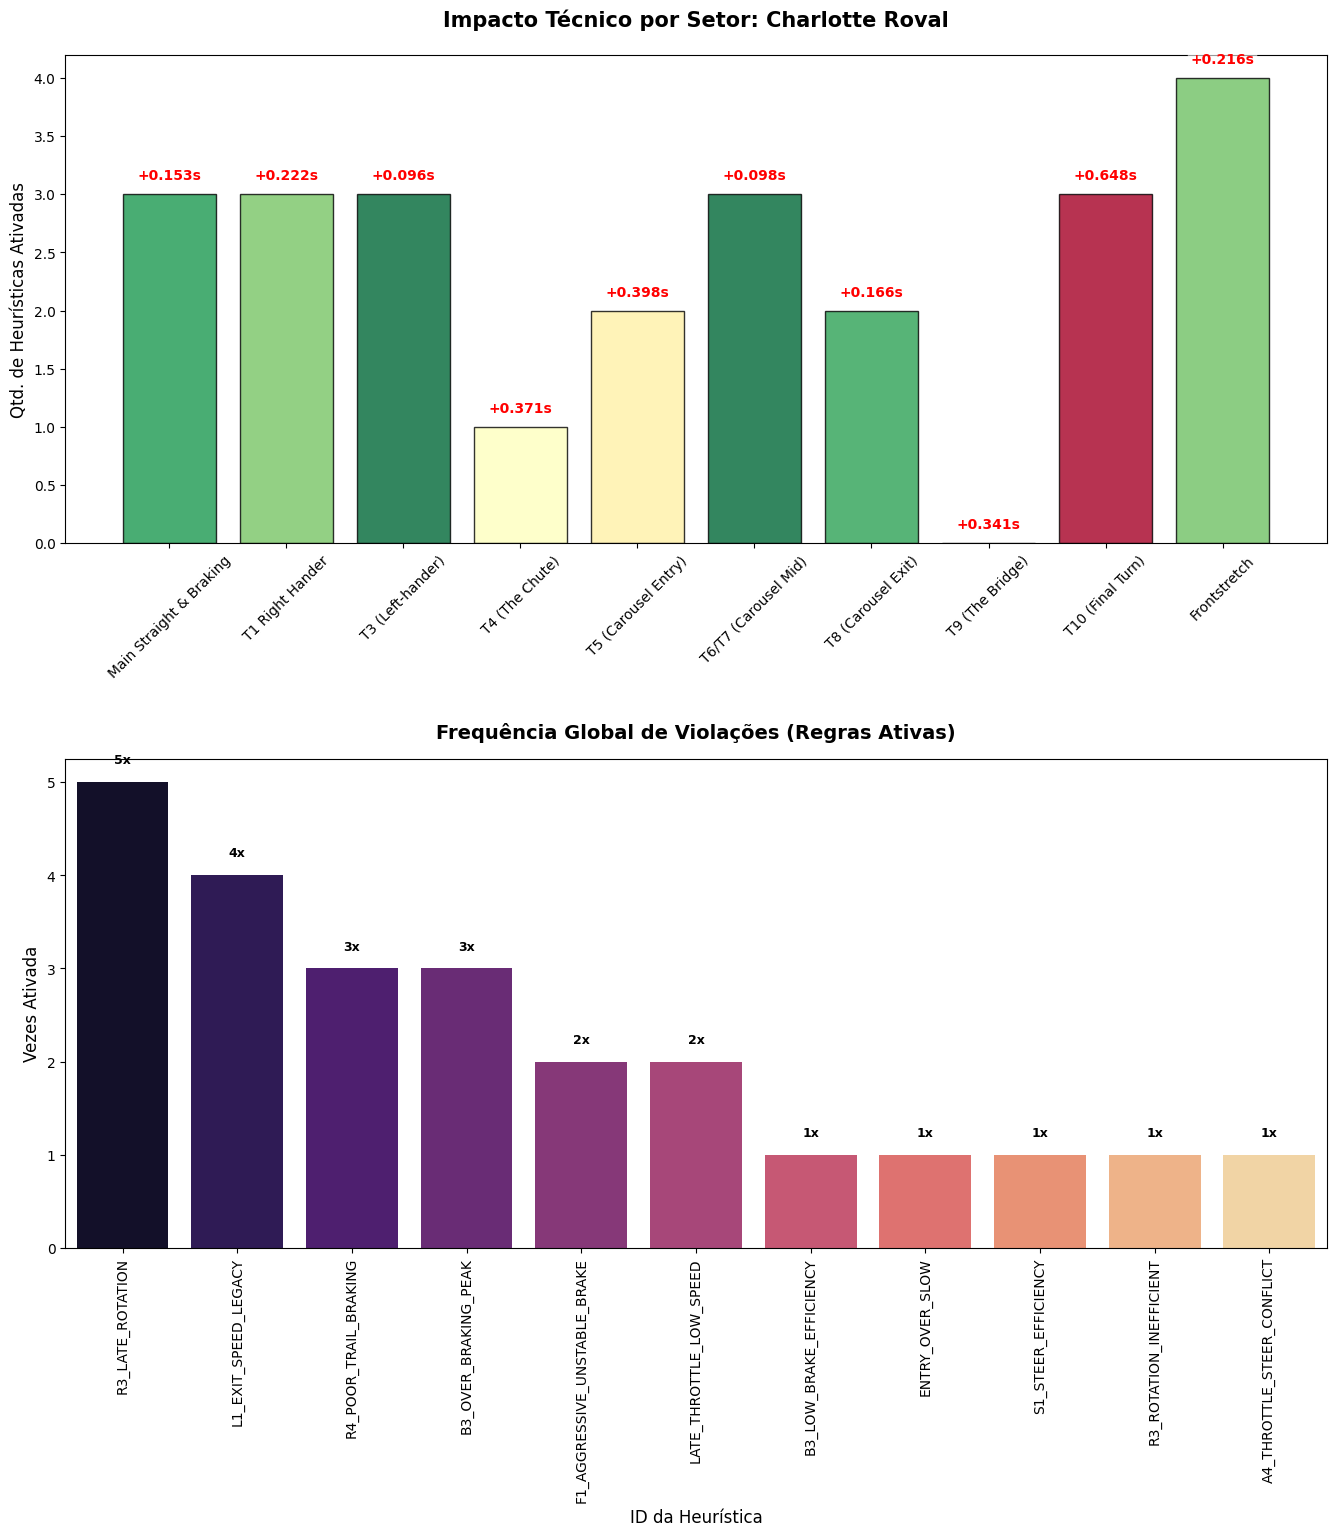

In [158]:
def plot_meta_analysis(df_insights, df_efficiency, track_name="Summit Point"):
    """
    Gera o dashboard com legibilidade corrigida para o gráfico inferior.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 16)) # Aumentei um pouco a altura total
    
    # --- PLOT 1: Distribuição de Alertas e Delta Time por Setor ---
    norm = plt.Normalize(df_insights['Delta_Time'].min(), df_insights['Delta_Time'].max())
    colors = plt.cm.RdYlGn_r(norm(df_insights['Delta_Time']))

    bars1 = ax1.bar(df_insights['Turn'], df_insights['Alerts_Count'], color=colors, edgecolor='black', alpha=0.8)
    ax1.set_title(f"Impacto Técnico por Setor: {track_name}", fontsize=15, fontweight='bold', pad=20)
    ax1.set_ylabel("Qtd. de Heurísticas Ativadas", fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        delta_val = df_insights.iloc[i]['Delta_Time']
        label = f"{delta_val:+.3f}s"
        txt_color = 'red' if delta_val > 0.05 else ('green' if delta_val < 0 else 'black')
        
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1, label,
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color=txt_color,
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))

    # --- PLOT 2: Eficiência das Heurísticas (Ranking Global Legível) ---
    # 1. Filtro: Remove regras com 0 ativações para limpar o gráfico
    df_efficiency_active = df_efficiency[df_efficiency["Trigger_Count"] > 0].copy()
    df_efficiency_active = df_efficiency_active.sort_values("Trigger_Count", ascending=False)
    
    # 2. Plotagem
    sns.barplot(data=df_efficiency_active, x="Rule_ID", y="Trigger_Count", palette="magma", ax=ax2)
    ax2.set_title("Frequência Global de Violações (Regras Ativas)", fontsize=14, fontweight='bold', pad=15)
    ax2.set_ylabel("Vezes Ativada", fontsize=12)
    
    # 3. CORREÇÃO DA LEGIBILIDADE: Rotação de 90 graus e alinhamento
    ax2.set_xticks(range(len(df_efficiency_active)))
    ax2.set_xticklabels(df_efficiency_active["Rule_ID"], rotation=90, ha='center', fontsize=10)
    ax2.set_xlabel("ID da Heurística", fontsize=12) # Adiciona label no eixo X
    
    # Adiciona os valores sobre as barras
    for i, v in enumerate(df_efficiency_active["Trigger_Count"]):
        ax2.text(i, v + 0.2, f'{v}x', ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout(pad=3.0) # Garante espaço entre os gráficos
    
    # Salvamento
    save_path = r"C:\Users\PC\Documents\GitHub\Racing4all\Iracing\img\dashboard_performance_legivel.png"
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Dashboard legível salvo em: {save_path}")
    
    plt.show()

# --- CHAMADA DA FUNÇÃO ---
plot_meta_analysis(df_insights, df_efficiency, track_name="Charlotte Roval")

# Resposta final com modelo de linguagem

In [159]:
from __future__ import annotations
import json
import numpy as np
import pandas as pd
from IPython.display import Markdown

# %% 1. SYSTEM PROMPT COM LÓGICA DE CAUSALIDADE (MEMÓRIA)
SYSTEM_PROMPT = """
Você é um coach de pilotagem profissional de SimRacing. 
Sua tarefa é analisar os deltas de tempo e as heurísticas para melhorar o desempenho no Charlotte Roval 2025.

Instruções de Prioridade e Memória:
1) Os dados JSON já estão ordenados pela magnitude da perda de tempo (do maior prejuízo para o menor). MANTENHA esta ordem.
2) Se um setor apresentar a categoria 'Legado', explique ao piloto que a perda de tempo ali NÃO é um erro de execução atual, mas sim uma consequência da saída ruim na curva anterior.
3) Use os nomes oficiais das curvas para contexto geográfico (ex: T7, Bus Stop, Oval T1).
4) Seja objetivo: gere no máximo 2 bullets por curva, focando na causa raiz (DNA técnico ou Legado).
5) Se o delta_time_s for negativo ou zero, apenas escreva: "Execução consistente com a referência."

Formato da resposta:
- "### Curva X: [Nome] (Δt = +Y.YYYs)"
- Bullets técnicos baseados nas heurísticas fornecidas.
- Finalize com "### Resumo de Foco Técnico" listando as 3 prioridades da volta.
""".strip()

# %% 2. FUNÇÕES DE SUPORTE AO PROMPT
def _safe_float(x):
    try:
        if x is None: return None
        x = float(x)
        return x if np.isfinite(x) else None
    except: return None

def build_tips_payload_by_sector(
    seg_cmp: pd.DataFrame,
    sectors_dt: pd.DataFrame,
    interp_B: dict,
    edges: list = CUSTOM_EDGES,
    max_tips_per_sector: int = 2,
    loss_threshold: float = 0.010 
) -> dict:
    payload = {
        "meta": {
            "track": "Charlotte Roval 2025",
            "note": "Setores ordenados por perda de tempo. Inclui diagnóstico de legado."
        },
        "sectors": []
    }

    temp_sectors = []
    for sid in seg_cmp["Sector"].unique():
        dt_row = sectors_dt.loc[sectors_dt["Sector"] == sid, "DeltaTime_s"]
        dt = _safe_float(dt_row.iloc[0]) if not dt_row.empty else 0.0
        if dt > loss_threshold:
            temp_sectors.append({
                "id": int(sid),
                "delta": dt,
                "name": SECTOR_NAMES.get(sid, f"Setor {sid}")
            })

    # Ordenação Decrescente: Prioridade para onde se perde mais tempo
    temp_sectors = sorted(temp_sectors, key=lambda x: x["delta"], reverse=True)

    for s_info in temp_sectors:
        sid = s_info["id"]
        df_sector = seg_cmp[seg_cmp["Sector"] == sid].copy()
        tips = generate_sector_tips(df_sector, max_tips=max_tips_per_sector)

        tips_min = []
        for t in tips:
            tips_min.append({
                "priority": int(t.get("priority", 3)),
                "category": str(t.get("category", "Geral")),
                "message": str(t.get("message", ""))
            })

        payload["sectors"].append({
            "id": sid,
            "name": s_info["name"],
            "delta_time_s": s_info["delta"],
            "tips": tips_min
        })

    return payload

def build_user_prompt(payload: dict) -> str:
    return (
        "Analise os dados de telemetria abaixo e gere o feedback de coaching.\n\n"
        f"JSON DATA:\n{json.dumps(payload, ensure_ascii=False, indent=2)}"
    )

def call_ollama_chat(model, system_prompt, user_prompt, temperature=0.1):
    import ollama
    resp = ollama.chat(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        options={"temperature": float(temperature), "num_predict": 500}
    )
    return resp["message"]["content"]

# %% 3. EXECUÇÃO FINAL
OLLAMA_MODEL = "gemma3:12b"

# Gerar o payload com os novos limites de 18 setores
payload = build_tips_payload_by_sector(
    seg_cmp=seg_cmp,
    sectors_dt=sectors_AB,
    interp_B=interp_B,
    edges=CUSTOM_EDGES
)

user_p = build_user_prompt(payload)

print(f"Enviando {len(payload['sectors'])} setores para análise do {OLLAMA_MODEL}...")
final_markdown = call_ollama_chat(
    model=OLLAMA_MODEL,
    system_prompt=SYSTEM_PROMPT,
    user_prompt=user_p
)

display(Markdown(final_markdown))

Enviando 10 setores para análise do gemma3:12b...


- ### Curva 9: T10 (Final Turn) (Δt = +0.6481678852668153s)
    * Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada.
    * Pico de frenagem excessivo: você está 'ancorando' demais o carro. Tente aplicar menos pressão máxima para manter a suspensão mais estável.

- ### Curva 5: T5 (Carousel Entry) (Δt = +0.39833975377352004s)
    * Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva.
    * Hesitação no acelerador: retomada irregular da potência. Foque em uma aplicação única e progressiva.

- ### Curva 4: T4 (The Chute) (Δt = +0.37073214671072563s)
    * Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva.

- ### Curva 8: T9 (The Bridge) (Δt = +0.34131243350290674s)
    * Execução consistente com a referência.

- ### Curva 2: T1 Right Hander (Δt = +0.22245210536853577s)
    * Pico de frenagem excessivo: você está 'ancorando' demais o carro. Tente aplicar menos pressão máxima para manter a suspensão mais estável.
    * Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva.

- ### Curva 10: Frontstretch (Δt = +0.21624408770408365s)
    * Rotação Atrasada: Você atingiu o

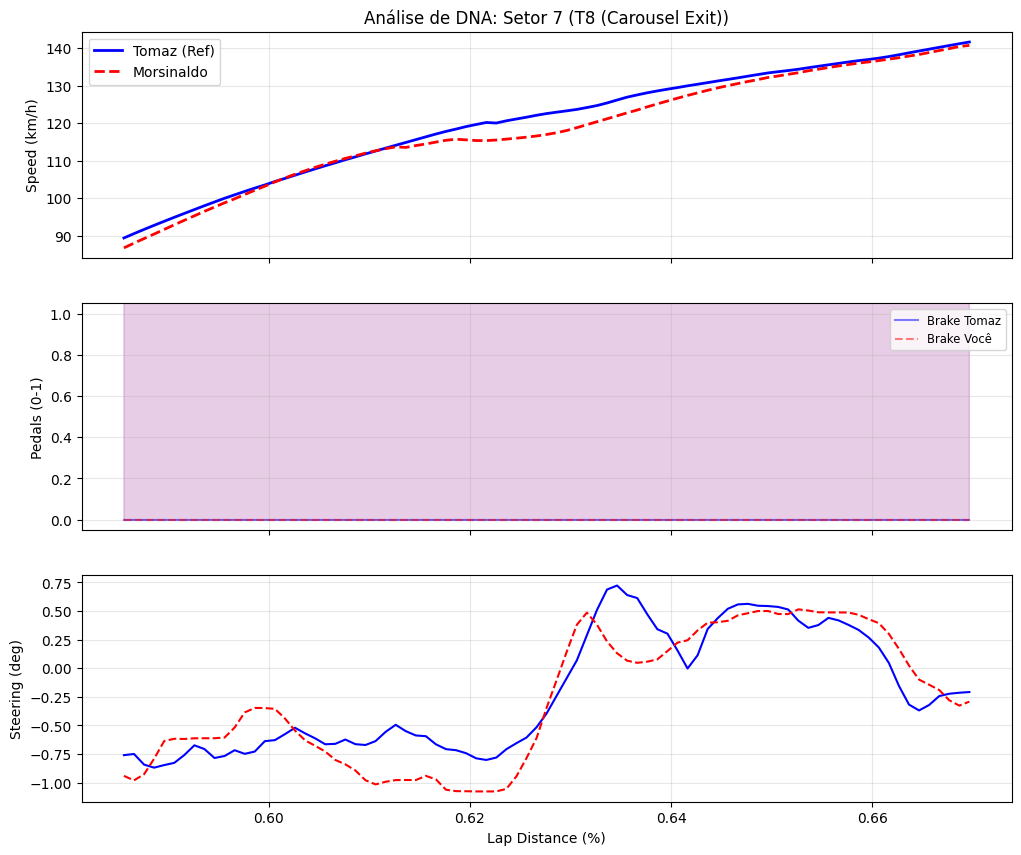

In [160]:
import matplotlib.pyplot as plt

def plot_sector_dna(interp_a, interp_b, sector_id, edges=CUSTOM_EDGES):
    # 1. Identifica os limites do setor
    start_pct = edges[sector_id - 1]
    end_pct = edges[sector_id]
    
    # 2. Filtra os dados de ambos os pilotos
    mask_a = (interp_a["LapDistPct"] >= start_pct) & (interp_a["LapDistPct"] <= end_pct)
    mask_b = (interp_b["LapDistPct"] >= start_pct) & (interp_b["LapDistPct"] <= end_pct)
    
    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    plt.subplots_adjust(hspace=0.2)
    
    # Subplot 1: VELOCIDADE (KPH)
    axs[0].plot(interp_a["LapDistPct"][mask_a], interp_a["speed"][mask_a], label="Tomaz (Ref)", color='blue', lw=2)
    axs[0].plot(interp_b["LapDistPct"][mask_b], interp_b["speed"][mask_b], label="Morsinaldo", color='red', lw=2, linestyle='--')
    axs[0].set_ylabel("Speed (km/h)")
    axs[0].set_title(f"Análise de DNA: Setor {sector_id} ({SECTOR_NAMES.get(sector_id)})")
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    # Subplot 2: PEDAIS (Brake & Throttle)
    axs[1].plot(interp_a["LapDistPct"][mask_a], interp_a["brake"][mask_a], color='blue', alpha=0.5, label="Brake Tomaz")
    axs[1].plot(interp_b["LapDistPct"][mask_b], interp_b["brake"][mask_b], color='red', alpha=0.5, linestyle='--', label="Brake Você")
    
    # Adicionando Throttle para ver a retomada
    axs[1].fill_between(interp_a["LapDistPct"][mask_a], 0, interp_a["throttle"][mask_a], color='blue', alpha=0.1)
    axs[1].fill_between(interp_b["LapDistPct"][mask_b], 0, interp_b["throttle"][mask_b], color='red', alpha=0.1)
    
    axs[1].set_ylabel("Pedals (0-1)")
    axs[1].set_ylim(-0.05, 1.05)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc='upper right', fontsize='small')

    # Subplot 3: VOLANTE (Steering)
    axs[2].plot(interp_a["LapDistPct"][mask_a], interp_a["SteeringWheelAngle"][mask_a], color='blue', lw=1.5)
    axs[2].plot(interp_b["LapDistPct"][mask_b], interp_b["SteeringWheelAngle"][mask_b], color='red', lw=1.5, linestyle='--')
    axs[2].set_ylabel("Steering (deg)")
    axs[2].set_xlabel("Lap Distance (%)")
    axs[2].grid(True, alpha=0.3)

    plt.show()

# EXECUÇÃO: Analisando o Setor 7
plot_sector_dna(interp_A, interp_B, sector_id=7)

Piloto A - Best lap: 8 (01:19.767)
Piloto B - Best lap: 6 (01:22.500)


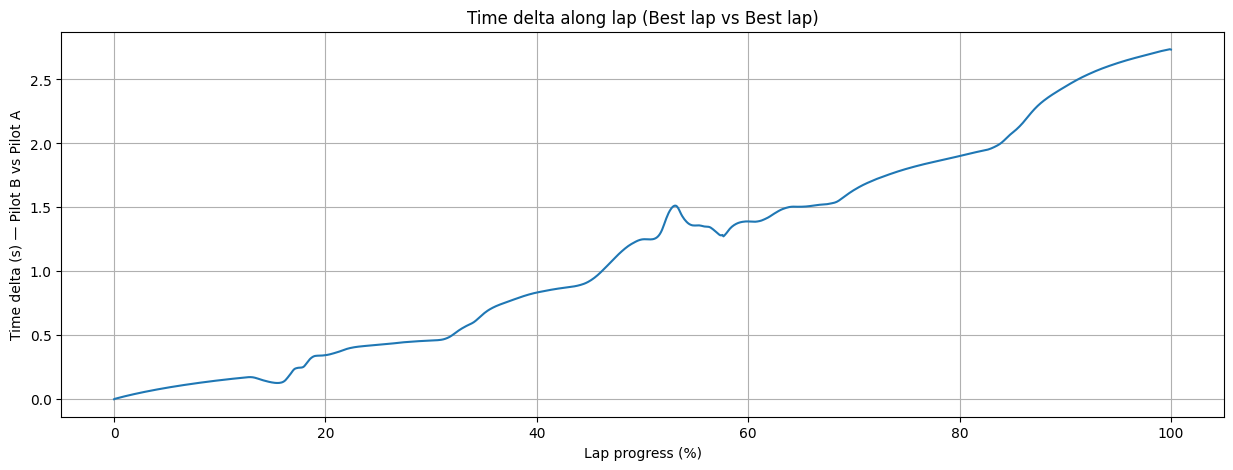

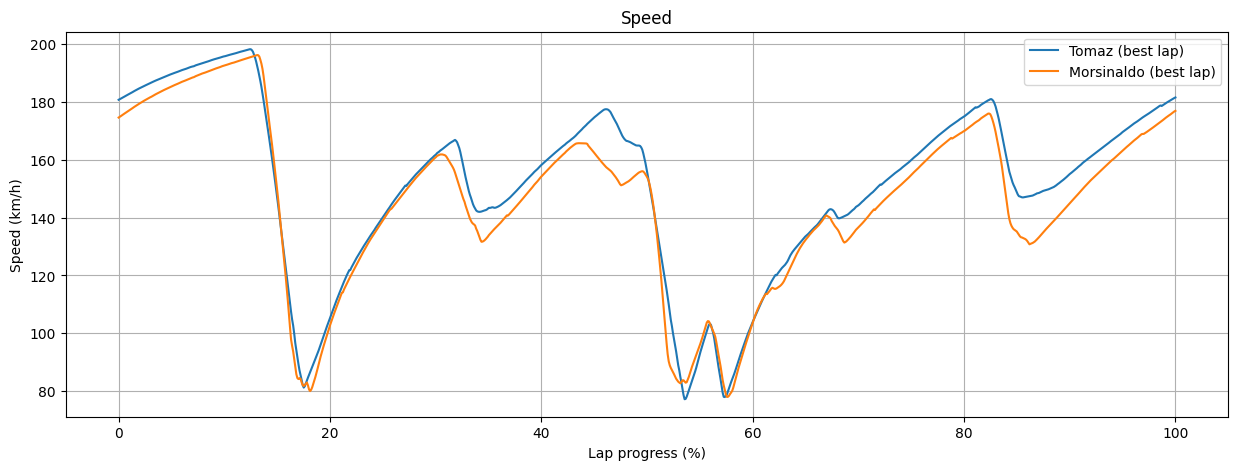

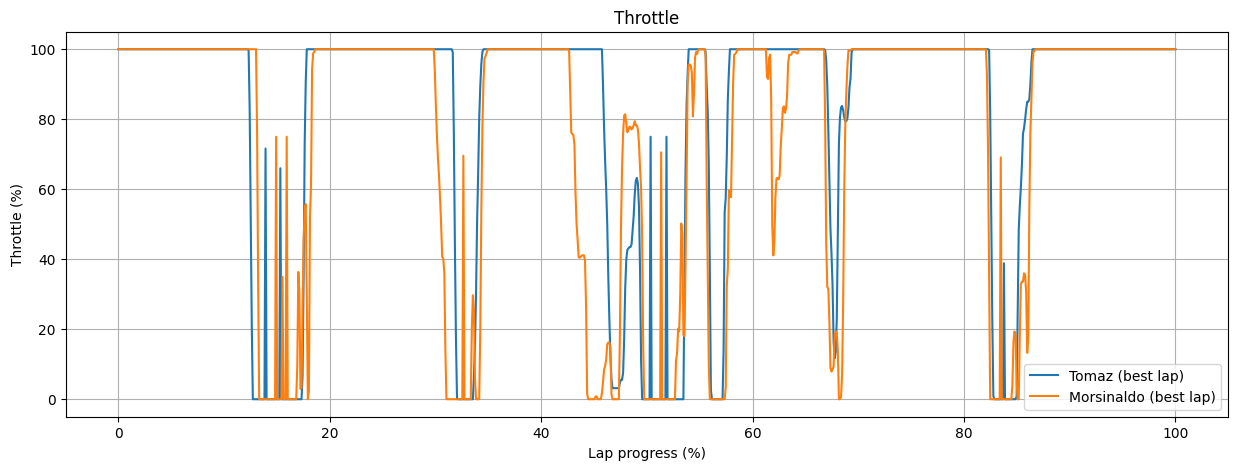

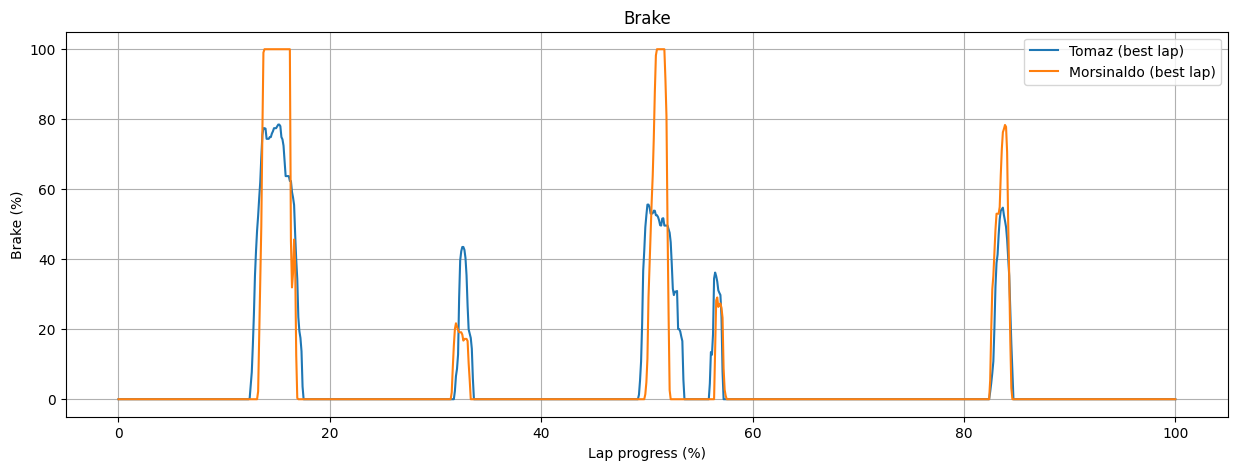

KeyError: 'RPM'

In [161]:
# --- Piloto A ---
lap_df_A = build_lap_validity_table(tomaz_df)
best_row_A = lap_df_A[lap_df_A["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_A = int(best_row_A["Lap"])

# --- Piloto B ---
lap_df_B = build_lap_validity_table(morsinaldo_df)
best_row_B = lap_df_B[lap_df_B["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_B = int(best_row_B["Lap"])

print(f"Piloto A - Best lap: {best_lap_A} ({format_laptime(best_row_A['LapTime_s'])})")
print(f"Piloto B - Best lap: {best_lap_B} ({format_laptime(best_row_B['LapTime_s'])})")

# Alinhamento por distância
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

g_A = tomaz_df[tomaz_df["Lap"] == best_lap_A]
g_B = morsinaldo_df[morsinaldo_df["Lap"] == best_lap_B]

interp_A = align_lap_by_dist(g_A, grid)
interp_B = align_lap_by_dist(g_B, grid)


# Time-loss curve (target vs reference)
time_loss = interp_B["t_rel"] - interp_A["t_rel"]

plt.figure(figsize=(15, 5))
plt.plot(grid * 100.0, time_loss)
plt.xlabel("Lap progress (%)")
plt.ylabel("Time delta (s) — Pilot B vs Pilot A")
plt.title("Time delta along lap (Best lap vs Best lap)")
plt.grid(True)
plt.show()

def quick_plot(yA, yB, label, ylab):
    plt.figure(figsize=(15, 5))
    plt.plot(grid * 100.0, yA, label="Tomaz (best lap)")
    plt.plot(grid * 100.0, yB, label="Morsinaldo (best lap)")
    plt.xlabel("Lap progress (%)")
    plt.ylabel(ylab)
    plt.title(label)
    plt.legend()
    plt.grid(True)
    plt.show()

quick_plot(interp_A["speed"],    interp_B["speed"],    "Speed",    "Speed (km/h)")
quick_plot(interp_A["throttle"], interp_B["throttle"], "Throttle", "Throttle (%)")
quick_plot(interp_A["brake"],    interp_B["brake"],    "Brake",    "Brake (%)")
quick_plot(interp_A["RPM"],interp_B["RPM"],"RPM","Engine speed (RPM)")
quick_plot(interp_A["Gear"],interp_B["Gear"],"Gear","Gear")

